# FNN Audit on the Full PPG Dataset

Notebook này triển khai thiết kế trong `STEP3B_FNN_AUDIT.md`.
FNN được tính độc lập trên từng cửa sổ và từng dạng dữ liệu; kết quả 60, 120
và 180 giây được lưu riêng trước khi tổng hợp ở cấp cửa sổ và cấp phiên.

Cấu hình chính:

- `R_tol = 15`, `A_tol = 2`, ngưỡng FNN `1%`, `max_m = 10`;
- Raw dùng độ trễ vật lý `0,20 giây`;
- Processed dùng độ trễ vật lý `0,16 giây`;
- chỉ dùng cửa sổ đạt quasi-stationarity của dạng dữ liệu tương ứng.


In [1]:
from pathlib import Path
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import spearmanr


def find_project_root():
    "Return the repository root."
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "phase1" / "src").is_dir():
            return candidate
    raise FileNotFoundError("Cannot locate the repository root.")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "phase1" / "src"
DATA_DIR = PROJECT_ROOT / "phase1" / "segmentated_data" / "dhdata"
OUTPUT_DIR = PROJECT_ROOT / "phase1" / "results" / "fnn"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = OUTPUT_DIR / "_cache"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dataloader.loader import get_data
from embedding.fnn import false_nearest_neighbors

WINDOW_SIZES = (60, 120, 180)
STATES = {0: "Awake", 1: "Drowsy"}
REPRESENTATIONS = ("raw", "processed")
TAU_SECONDS = {"raw": 0.20, "processed": 0.16}
R_TOL = 15.0
A_TOL = 2.0
FNN_THRESHOLD = 1.0
MAX_M = 10
THEILER = 0
FORCE_RECOMPUTE = False

R_TOL_VALUES = (10.0, 15.0, 20.0)
A_TOL_VALUES = (1.5, 2.0, 2.5)
THRESHOLD_VALUES = (0.5, 1.0, 2.0)
THEILER_MULTIPLIERS = (0, 1, 2)

INDEX_PATH = DATA_DIR / "segments_index.csv"
WINDOW_RESULTS_PATH = OUTPUT_DIR / "fnn_window_results.csv"
SESSION_SUMMARY_PATH = OUTPUT_DIR / "fnn_session_summary.csv"
CURVE_RESULTS_PATH = OUTPUT_DIR / "fnn_curves.csv"
SENSITIVITY_RESULTS_PATH = OUTPUT_DIR / "fnn_sensitivity_results.csv"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Hàm dùng chung

Các hàm dưới đây giữ nguyên định danh cửa sổ, dùng đúng độ trễ theo dạng dữ
liệu và không thay `selected_m=None` bằng `max_m`.


In [2]:
RESULT_COLUMNS = [
    "session",
    "window_id",
    "window_size_s",
    "label",
    "representation",
    "fs",
    "tau_samples",
    "max_m",
    "selected_m",
    "min_fnn_percent",
    "valid_count_at_selected_m",
    "m_found",
]
CURVE_COLUMNS = [
    "session",
    "window_id",
    "window_size_s",
    "label",
    "representation",
    "dimension",
    "fnn_percent",
    "valid_count",
]


def natural_key(value):
    "Return a natural-sort key."
    parts = re.split(r"(\d+)", str(value))
    return [int(part) if part.isdigit() else part.lower() for part in parts]


def parse_boolean(series):
    "Return a validated Boolean series."
    if pd.api.types.is_bool_dtype(series):
        return series
    values = series.astype(str).str.strip().str.lower()
    result = values.map({"true": True, "false": False})
    if result.isna().any():
        raise ValueError("Boolean column contains invalid values.")
    return result.astype(bool)


def tau_in_samples(representation, fs):
    "Convert the fixed physical delay to samples."
    key = representation.lower()
    return int(round(TAU_SECONDS[key] * fs))


def selected_from_curve(dims, percentages, threshold):
    "Select the first dimension below a threshold."
    candidates = np.flatnonzero(percentages <= threshold)
    if candidates.size == 0:
        return None
    return int(dims[candidates[0]])


def analyze_signal(signal, tau, **overrides):
    "Run the FNN core with the primary configuration."
    parameters = {
        "max_m": MAX_M,
        "r_tol": R_TOL,
        "a_tol": A_TOL,
        "theiler": THEILER,
        "fnn_threshold": FNN_THRESHOLD,
    }
    parameters.update(overrides)
    return false_nearest_neighbors(signal, tau=tau, **parameters)


def size_result_path(window_size):
    "Return the window-level result path for one size."
    return CACHE_DIR / f"fnn_{window_size}_results.csv"


def size_curve_path(window_size):
    "Return the curve result path for one size."
    return CACHE_DIR / f"fnn_{window_size}_curves.csv"


def expected_count(index, window_size):
    "Return the expected rows for one window size."
    subset = index[index["window_size_s"] == window_size]
    raw = int(subset["stationarity_pass_raw"].sum())
    processed = int(subset["stationarity_pass_processed"].sum())
    return raw + processed


def cache_is_complete(path, expected_rows, window_size):
    "Check a cached window-level result."
    if not path.is_file():
        return False
    cached = pd.read_csv(path)
    required = set(RESULT_COLUMNS)
    if not required.issubset(cached.columns):
        return False
    if len(cached) != expected_rows:
        return False
    return (
        cached["window_size_s"].eq(window_size).all()
        and cached["max_m"].eq(MAX_M).all()
    )


def summarize_one_signal(row, signal):
    "Return one result row and its FNN curve."
    tau = tau_in_samples(row["representation"], row["fs"])
    try:
        dims, percentages, counts, selected_m = analyze_signal(
            signal,
            tau,
        )
    except (TypeError, ValueError) as exc:
        context = (
            f"{row['session']} | {row['window_size_s']} s | "
            f"{row['label']} | {row['representation']} | "
            f"window {row['window_id']}"
        )
        raise RuntimeError(f"FNN failed for {context}: {exc}") from exc

    selected_index = np.flatnonzero(dims == selected_m)
    valid_at_selected = (
        int(counts[selected_index[0]])
        if selected_index.size
        else np.nan
    )
    result = {
        **row,
        "tau_samples": tau,
        "max_m": MAX_M,
        "selected_m": selected_m,
        "min_fnn_percent": float(percentages.min()),
        "valid_count_at_selected_m": valid_at_selected,
        "m_found": selected_m is not None,
    }
    curve = pd.DataFrame({
        **{
            key: [row[key]] * len(dims)
            for key in (
                "session",
                "window_id",
                "window_size_s",
                "label",
                "representation",
            )
        },
        "dimension": dims,
        "fnn_percent": percentages,
        "valid_count": counts,
    })
    return result, curve


def run_window_size(window_size, index, sessions):
    "Run and save FNN for every eligible window of one size."
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    records = []
    curves = []
    for number, session in enumerate(sessions, start=1):
        for representation in REPRESENTATIONS:
            awake, drowsy = get_data(
                session,
                data_dir=DATA_DIR,
                window_sizes=window_size,
                stationarity=representation,
            )
            state_batches = {"Awake": awake, "Drowsy": drowsy}
            for label, state_data in state_batches.items():
                batch = state_data[window_size]
                for array_index, signal in enumerate(
                    batch[representation]
                ):
                    row = {
                        "session": session,
                        "window_id": int(
                            batch["window_id"][array_index]
                        ),
                        "window_size_s": window_size,
                        "label": label,
                        "representation": representation.title(),
                        "fs": float(batch["fs"]),
                    }
                    result, curve = summarize_one_signal(row, signal)
                    records.append(result)
                    curves.append(curve)

        checkpoint = pd.DataFrame(records, columns=RESULT_COLUMNS)
        checkpoint.to_csv(size_result_path(window_size), index=False)
        print(
            f"{window_size} s | {number:02d}/{len(sessions)} | "
            f"{session}"
        )

    results = pd.DataFrame(records, columns=RESULT_COLUMNS)
    curve_results = pd.concat(curves, ignore_index=True)
    results.to_csv(size_result_path(window_size), index=False)
    curve_results.to_csv(size_curve_path(window_size), index=False)
    return results, curve_results


def load_aggregate_window_size(window_size, expected_rows):
    "Load one size from the aggregate result files."
    if not WINDOW_RESULTS_PATH.is_file() or not CURVE_RESULTS_PATH.is_file():
        return None

    results = pd.read_csv(WINDOW_RESULTS_PATH)
    results = results[results["window_size_s"] == window_size].copy()
    curves = pd.read_csv(CURVE_RESULTS_PATH)
    curves = curves[curves["window_size_s"] == window_size].copy()
    complete = (
        len(results) == expected_rows
        and len(curves) == expected_rows * MAX_M
        and results["max_m"].eq(MAX_M).all()
    )
    if not complete:
        return None

    results["m_found"] = parse_boolean(results["m_found"])
    print(f"Loaded aggregate results: {window_size} s")
    return results, curves


def load_or_run_window_size(window_size, index, sessions):
    "Load valid results or run one window-size experiment."
    expected_rows = expected_count(index, window_size)
    if not FORCE_RECOMPUTE:
        aggregate = load_aggregate_window_size(
            window_size,
            expected_rows,
        )
        if aggregate is not None:
            return aggregate

    result_path = size_result_path(window_size)
    curve_path = size_curve_path(window_size)
    complete = cache_is_complete(
        result_path,
        expected_rows,
        window_size,
    )
    if FORCE_RECOMPUTE or not complete or not curve_path.is_file():
        return run_window_size(window_size, index, sessions)

    results = pd.read_csv(result_path)
    results["m_found"] = parse_boolean(results["m_found"])
    curves = pd.read_csv(curve_path)
    print(f"Loaded temporary cache: {result_path.name}")
    return results, curves


def iqr(values):
    "Return the interquartile range."
    values = pd.Series(values).dropna()
    if values.empty:
        return np.nan
    return values.quantile(0.75) - values.quantile(0.25)


def first_mode(values):
    "Return the smallest mode or NaN."
    modes = pd.Series(values).dropna().mode()
    return np.nan if modes.empty else float(modes.iloc[0])


def safe_spearman(x, y):
    "Return Spearman correlation when defined."
    paired = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(paired) < 3:
        return np.nan
    if paired["x"].nunique() < 2 or paired["y"].nunique() < 2:
        return np.nan
    return float(spearmanr(paired["x"], paired["y"]).statistic)


## Kiểm tra dữ liệu đầu vào

Inventory được tính trực tiếp từ `segments_index.csv`, tách riêng pass flag của
Raw và Processed.


In [3]:
index = pd.read_csv(INDEX_PATH)
for column in (
    "stationarity_pass_raw",
    "stationarity_pass_processed",
):
    index[column] = parse_boolean(index[column])

sessions = sorted(index["session"].unique(), key=natural_key)
inventory_rows = []
for window_size in WINDOW_SIZES:
    subset = index[index["window_size_s"] == window_size]
    for label_code, label in STATES.items():
        state_rows = subset[subset["label"] == label_code]
        for representation in REPRESENTATIONS:
            pass_column = f"stationarity_pass_{representation}"
            inventory_rows.append({
                "window_size_s": window_size,
                "label": label,
                "representation": representation.title(),
                "n_windows": int(state_rows[pass_column].sum()),
            })

inventory = pd.DataFrame(inventory_rows)
display(inventory)
print(f"Sessions: {len(sessions)}")
print(f"Expected window-representation rows: {inventory['n_windows'].sum()}")


,window_size_s,label,representation,n_windows
0,60,Awake,Raw,550
1,60,Awake,Processed,596
2,60,Drowsy,Raw,267
3,60,Drowsy,Processed,305
4,120,Awake,Raw,245
5,120,Awake,Processed,269
6,120,Drowsy,Raw,118
7,120,Drowsy,Processed,136
8,180,Awake,Raw,147
9,180,Awake,Processed,161


Sessions: 20
Expected window-representation rows: 2942


## Kiểm tra tích hợp core

Chạy một cửa sổ Processed 60 giây để xác nhận shape, valid-neighbor count và
quy tắc chọn chiều đầu tiên đạt ngưỡng 1%.


In [4]:
sanity_session = sessions[0]
sanity_awake, _ = get_data(
    sanity_session,
    data_dir=DATA_DIR,
    window_sizes=60,
    stationarity="processed",
)
sanity_batch = sanity_awake[60]
sanity_signal = sanity_batch["processed"][0]
sanity_tau = tau_in_samples("processed", sanity_batch["fs"])
sanity_dims, sanity_fnn, sanity_counts, sanity_m = analyze_signal(
    sanity_signal,
    sanity_tau,
)

assert sanity_dims.ndim == sanity_fnn.ndim == sanity_counts.ndim == 1
assert len(sanity_dims) == len(sanity_fnn) == len(sanity_counts)
assert np.isfinite(sanity_fnn).all()
assert (sanity_counts > 0).all()
assert sanity_m == selected_from_curve(
    sanity_dims,
    sanity_fnn,
    FNN_THRESHOLD,
)

sanity_table = pd.DataFrame({
    "dimension": sanity_dims,
    "fnn_percent": sanity_fnn,
    "valid_count": sanity_counts,
})
print(
    f"Session: {sanity_session} | tau={sanity_tau} | "
    f"selected_m={sanity_m}"
)
display(sanity_table)


Session: sample_1.csv | tau=8 | selected_m=5


,dimension,fnn_percent,valid_count
0,1,97.493316,2992
1,2,37.701072,2984
2,3,8.501344,2976
3,4,2.055256,2968
4,5,0.337838,2960
5,6,0.271003,2952
6,7,0.101902,2944
7,8,0.068120,2936
8,9,0.239071,2928
9,10,0.547945,2920


## Experiment A — tất cả cửa sổ 60 giây

Kết quả và toàn bộ FNN curves được lưu trước khi chạy kích thước tiếp theo.


In [5]:
fnn_60_results, fnn_60_curves = load_or_run_window_size(
    60,
    index,
    sessions,
)
display(
    fnn_60_results
    .groupby(["label", "representation"], observed=True)
    .agg(
        n_windows=("m_found", "size"),
        n_m_found=("m_found", "sum"),
    )
    .reset_index()
)
print(f"Rows analyzed: {len(fnn_60_results)}")


,label,representation,n_windows,n_m_found
0,Awake,Processed,596,419
1,Awake,Raw,550,117
2,Drowsy,Processed,305,205
3,Drowsy,Raw,267,70


## Experiment B — tất cả cửa sổ 120 giây

Lượt chạy này độc lập với kết quả 60 giây.


In [6]:
fnn_120_results, fnn_120_curves = load_or_run_window_size(
    120,
    index,
    sessions,
)
display(
    fnn_120_results
    .groupby(["label", "representation"], observed=True)
    .agg(
        n_windows=("m_found", "size"),
        n_m_found=("m_found", "sum"),
    )
    .reset_index()
)
print(f"Rows analyzed: {len(fnn_120_results)}")


,label,representation,n_windows,n_m_found
0,Awake,Processed,269,190
1,Awake,Raw,245,56
2,Drowsy,Processed,136,96
3,Drowsy,Raw,118,31


## Experiment C — tất cả cửa sổ 180 giây

Lượt chạy này độc lập với kết quả 60 và 120 giây.


In [7]:
fnn_180_results, fnn_180_curves = load_or_run_window_size(
    180,
    index,
    sessions,
)
display(
    fnn_180_results
    .groupby(["label", "representation"], observed=True)
    .agg(
        n_windows=("m_found", "size"),
        n_m_found=("m_found", "sum"),
    )
    .reset_index()
)
print(f"Rows analyzed: {len(fnn_180_results)}")


,label,representation,n_windows,n_m_found
0,Awake,Processed,161,112
1,Awake,Raw,147,38
2,Drowsy,Processed,77,53
3,Drowsy,Raw,71,17


## Hợp nhất kết quả

Ba kết quả độc lập được kiểm tra và hợp nhất sau khi đã lưu riêng.


In [8]:
fnn_results = pd.concat(
    [fnn_60_results, fnn_120_results, fnn_180_results],
    ignore_index=True,
)
fnn_curves = pd.concat(
    [fnn_60_curves, fnn_120_curves, fnn_180_curves],
    ignore_index=True,
)
fnn_results["m_found"] = parse_boolean(fnn_results["m_found"])

expected_total = int(inventory["n_windows"].sum())
assert len(fnn_results) == expected_total
assert not fnn_results.duplicated([
    "session",
    "window_id",
    "window_size_s",
    "representation",
]).any()
assert fnn_results.loc[~fnn_results["m_found"], "selected_m"].isna().all()
assert (
    fnn_results.loc[fnn_results["m_found"], "selected_m"] <= MAX_M
).all()

fnn_results[RESULT_COLUMNS].to_csv(WINDOW_RESULTS_PATH, index=False)
fnn_curves[CURVE_COLUMNS].to_csv(CURVE_RESULTS_PATH, index=False)
print(f"Window-level rows: {len(fnn_results)}")
print(f"Curve rows: {len(fnn_curves)}")
print(f"Saved: {WINDOW_RESULTS_PATH}")


Window-level rows: 2942
Curve rows: 29420
Saved: C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\phase1\results\fnn\fnn_window_results.csv


## Coverage

Coverage được báo theo kích thước cửa sổ, trạng thái và dạng dữ liệu; bảng thứ
hai xác định các phiên có failure rate cao nhất.


In [9]:
GROUP_KEYS = ["window_size_s", "label", "representation"]
coverage = (
    fnn_results
    .groupby(GROUP_KEYS, observed=True)
    .agg(
        n_windows=("m_found", "size"),
        n_m_found=("m_found", "sum"),
    )
    .reset_index()
)
coverage["n_none"] = coverage["n_windows"] - coverage["n_m_found"]
coverage["success_rate_pct"] = (
    100.0 * coverage["n_m_found"] / coverage["n_windows"]
)

failure_by_session = (
    fnn_results
    .assign(m_none=lambda frame: ~frame["m_found"])
    .groupby("session", observed=True)
    .agg(
        n_windows=("m_none", "size"),
        n_none=("m_none", "sum"),
    )
    .assign(
        failure_rate_pct=lambda frame: (
            100.0 * frame["n_none"] / frame["n_windows"]
        )
    )
    .sort_values(["failure_rate_pct", "n_none"], ascending=False)
    .reset_index()
)

display(coverage)
display(failure_by_session.head(10))


,window_size_s,label,representation,n_windows,n_m_found,n_none,success_rate_pct
0,60,Awake,Processed,596,419,177,70.302013
1,60,Awake,Raw,550,117,433,21.272727
2,60,Drowsy,Processed,305,205,100,67.213115
3,60,Drowsy,Raw,267,70,197,26.217228
4,120,Awake,Processed,269,190,79,70.631970
5,120,Awake,Raw,245,56,189,22.857143
6,120,Drowsy,Processed,136,96,40,70.588235
7,120,Drowsy,Raw,118,31,87,26.271186
8,180,Awake,Processed,161,112,49,69.565217
9,180,Awake,Raw,147,38,109,25.850340


,session,n_windows,n_none,failure_rate_pct
0,sample_23.csv,184,136,73.913043
1,sample_6.csv,163,120,73.619632
2,sample_4.csv,158,112,70.886076
3,sample_11.csv,129,91,70.542636
4,sample_13.csv,162,109,67.283951
5,sample_8.csv,161,105,65.217391
6,sample_10.csv,121,73,60.330579
7,sample_21.csv,136,82,60.294118
8,sample_17.csv,147,88,59.863946
9,sample_7.csv,156,85,54.487179


## Phân phối selected m

Thống kê và count plot chỉ sử dụng các cửa sổ tìm được `selected_m`.


In [10]:
found_results = fnn_results[fnn_results["m_found"]].copy()
distribution = (
    found_results
    .groupby(GROUP_KEYS, observed=True)["selected_m"]
    .agg(
        n="size",
        median_m="median",
        iqr_m=iqr,
        min_m="min",
        max_m="max",
        mode_m=first_mode,
    )
    .reset_index()
)
display(distribution)


,window_size_s,label,representation,n,median_m,iqr_m,min_m,max_m,mode_m
0,60,Awake,Processed,419,6.0,2.0,4.0,10.0,5.0
1,60,Awake,Raw,117,6.0,2.0,4.0,10.0,6.0
2,60,Drowsy,Processed,205,6.0,2.0,4.0,10.0,5.0
3,60,Drowsy,Raw,70,6.0,2.0,4.0,10.0,5.0
4,120,Awake,Processed,190,6.0,2.0,4.0,9.0,6.0
5,120,Awake,Raw,56,6.0,2.0,4.0,10.0,6.0
6,120,Drowsy,Processed,96,6.0,1.0,5.0,10.0,6.0
7,120,Drowsy,Raw,31,6.0,1.5,5.0,10.0,6.0
8,180,Awake,Processed,112,6.0,1.0,5.0,9.0,6.0
9,180,Awake,Raw,38,6.0,1.0,5.0,9.0,6.0


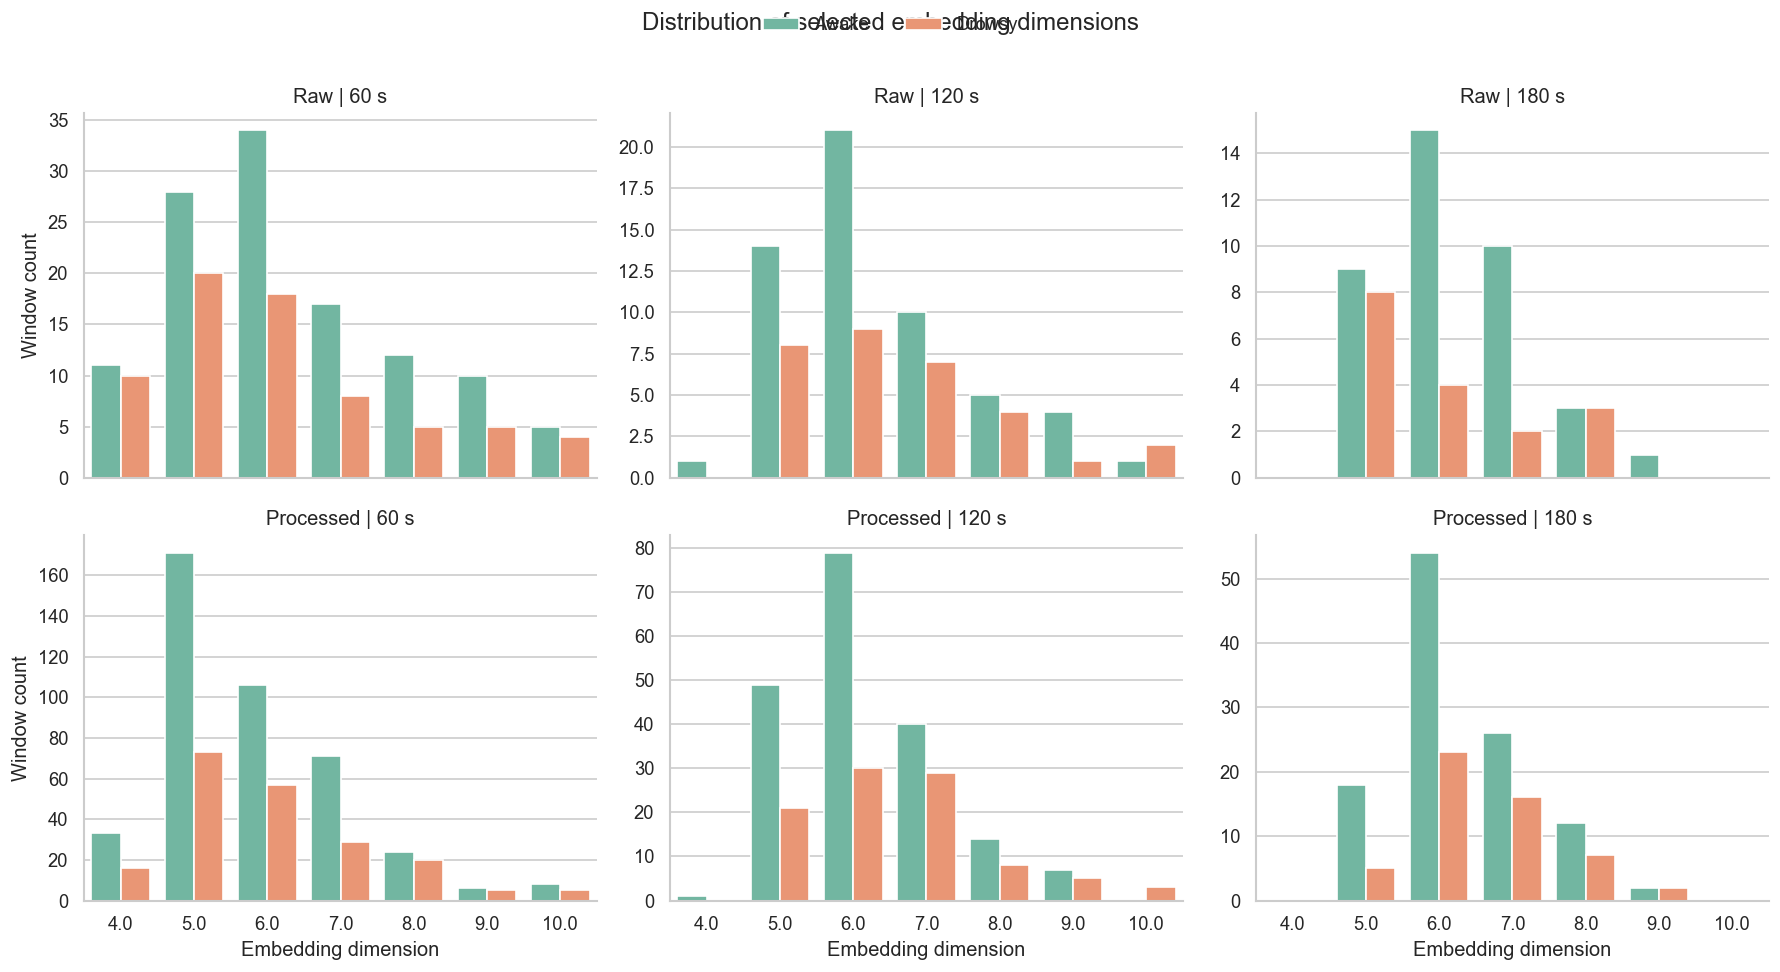

In [11]:
figure, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for row_index, representation in enumerate(("Raw", "Processed")):
    for column_index, window_size in enumerate(WINDOW_SIZES):
        axis = axes[row_index, column_index]
        subset = found_results[
            (found_results["representation"] == representation)
            & (found_results["window_size_s"] == window_size)
        ]
        sns.countplot(
            data=subset,
            x="selected_m",
            hue="label",
            palette="Set2",
            ax=axis,
        )
        axis.set_title(f"{representation} | {window_size} s")
        axis.set_xlabel("Embedding dimension")
        axis.set_ylabel("Window count" if column_index == 0 else "")
        if not (row_index == 0 and column_index == 0):
            axis.get_legend().remove()

handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].get_legend().remove()
figure.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
)
figure.suptitle("Distribution of selected embedding dimensions", y=1.01)
figure.tight_layout()
plt.show()


## Tổng hợp cấp phiên

Phiên là observational unit chính cho các so sánh Awake–Drowsy.


In [12]:
SESSION_KEYS = [
    "session",
    "window_size_s",
    "label",
    "representation",
]
session_summary = (
    fnn_results
    .groupby(SESSION_KEYS, observed=True)
    .agg(
        n_windows=("m_found", "size"),
        n_m_found=("m_found", "sum"),
        median_m=("selected_m", "median"),
        iqr_m=("selected_m", iqr),
        mode_m=("selected_m", first_mode),
    )
    .reset_index()
)
session_summary["m_found_rate_pct"] = (
    100.0
    * session_summary["n_m_found"]
    / session_summary["n_windows"]
)
session_summary.to_csv(SESSION_SUMMARY_PATH, index=False)

display(session_summary.head(12))
print(f"Session-level rows: {len(session_summary)}")
print(f"Saved: {SESSION_SUMMARY_PATH}")


,session,window_size_s,label,representation,n_windows,n_m_found,median_m,iqr_m,mode_m,m_found_rate_pct
0,sample_1.csv,60,Awake,Processed,24,24,5.0,0.00,5.0,100.000000
1,sample_1.csv,60,Awake,Raw,14,14,6.0,0.75,6.0,100.000000
2,sample_1.csv,60,Drowsy,Processed,7,7,5.0,1.00,5.0,100.000000
3,sample_1.csv,60,Drowsy,Raw,3,3,5.0,0.50,5.0,100.000000
4,sample_1.csv,120,Awake,Processed,11,11,5.0,1.00,5.0,100.000000
5,sample_1.csv,120,Awake,Raw,8,8,6.5,1.25,7.0,100.000000
6,sample_1.csv,120,Drowsy,Processed,1,1,5.0,0.00,5.0,100.000000
7,sample_1.csv,180,Awake,Processed,6,6,6.0,0.75,6.0,100.000000
8,sample_1.csv,180,Awake,Raw,5,5,7.0,1.00,7.0,100.000000
9,sample_1.csv,180,Drowsy,Processed,1,1,5.0,0.00,5.0,100.000000


Session-level rows: 238
Saved: C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\phase1\results\fnn\fnn_session_summary.csv


## Awake so với Drowsy

So sánh ghép cặp sử dụng trung vị `m` của mỗi phiên, tách riêng theo kích thước
cửa sổ và dạng dữ liệu.


In [13]:
state_pairs = (
    session_summary
    .pivot_table(
        index=["session", "window_size_s", "representation"],
        columns="label",
        values="median_m",
    )
    .dropna(subset=["Awake", "Drowsy"])
    .reset_index()
)
state_pairs["delta_m"] = state_pairs["Drowsy"] - state_pairs["Awake"]

state_summary = (
    state_pairs
    .groupby(["window_size_s", "representation"], observed=True)
    ["delta_m"]
    .agg(
        paired_n="size",
        median_delta="median",
        iqr_delta=iqr,
        pct_higher=lambda values: 100.0 * (values > 0).mean(),
        pct_equal=lambda values: 100.0 * (values == 0).mean(),
        pct_lower=lambda values: 100.0 * (values < 0).mean(),
    )
    .reset_index()
)
display(state_summary)


,window_size_s,representation,paired_n,median_delta,iqr_delta,pct_higher,pct_equal,pct_lower
0,60,Processed,20,0.0,1.125,40.000000,30.000000,30.000000
1,60,Raw,18,-0.5,1.875,38.888889,5.555556,55.555556
2,120,Processed,20,0.0,1.000,45.000000,35.000000,20.000000
3,120,Raw,12,0.0,1.625,41.666667,16.666667,41.666667
4,180,Processed,17,0.0,1.500,47.058824,23.529412,29.411765
5,180,Raw,9,0.0,1.000,22.222222,33.333333,44.444444


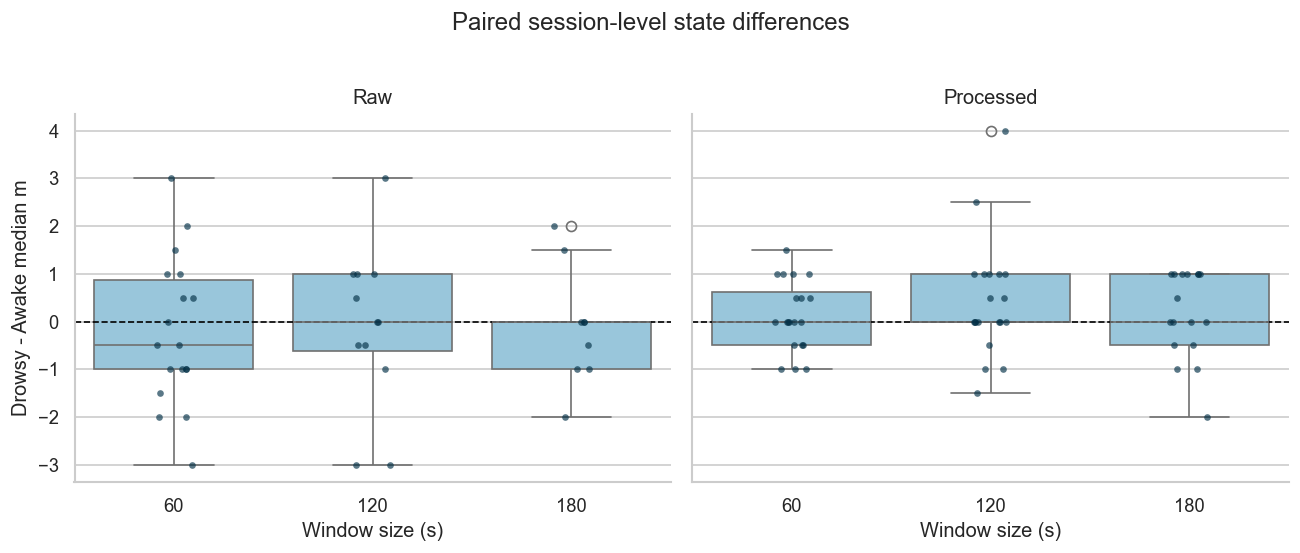

In [14]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for axis, representation in zip(axes, ("Raw", "Processed")):
    subset = state_pairs[
        state_pairs["representation"] == representation
    ]
    sns.boxplot(
        data=subset,
        x="window_size_s",
        y="delta_m",
        color="#8ecae6",
        ax=axis,
    )
    sns.stripplot(
        data=subset,
        x="window_size_s",
        y="delta_m",
        color="#023047",
        alpha=0.65,
        size=4,
        ax=axis,
    )
    axis.axhline(0.0, color="black", linewidth=1, linestyle="--")
    axis.set_title(representation)
    axis.set_xlabel("Window size (s)")
    axis.set_ylabel("Drowsy - Awake median m" if axis is axes[0] else "")

figure.suptitle("Paired session-level state differences", y=1.02)
figure.tight_layout()
plt.show()


## Raw so với Processed

Chỉ ghép các analysis window có kết quả FNN hợp lệ ở cả hai dạng dữ liệu.


In [15]:
PAIR_KEYS = ["session", "window_id", "window_size_s", "label"]
raw_results = fnn_results[fnn_results["representation"] == "Raw"]
processed_results = fnn_results[
    fnn_results["representation"] == "Processed"
]
representation_pairs = raw_results.merge(
    processed_results,
    on=PAIR_KEYS,
    suffixes=("_raw", "_processed"),
    validate="one_to_one",
)
representation_pairs = representation_pairs[
    representation_pairs["m_found_raw"]
    & representation_pairs["m_found_processed"]
].copy()
representation_pairs["delta_m"] = (
    representation_pairs["selected_m_processed"]
    - representation_pairs["selected_m_raw"]
)

representation_summary = (
    representation_pairs
    .groupby(["window_size_s", "label"], observed=True)
    .agg(
        n_pairs=("delta_m", "size"),
        median_delta=("delta_m", "median"),
        iqr_delta=("delta_m", iqr),
        exact_agreement_pct=(
            "delta_m",
            lambda values: 100.0 * (values == 0).mean(),
        ),
        within_1_dimension_pct=(
            "delta_m",
            lambda values: 100.0 * (values.abs() <= 1).mean(),
        ),
    )
    .reset_index()
)
display(representation_summary)


,window_size_s,label,n_pairs,median_delta,iqr_delta,exact_agreement_pct,within_1_dimension_pct
0,60,Awake,89,-1.0,3.00,15.730337,61.797753
1,60,Drowsy,45,0.0,2.00,31.111111,57.777778
2,120,Awake,44,0.0,3.00,25.000000,68.181818
3,120,Drowsy,20,0.0,3.00,25.000000,65.000000
4,180,Awake,28,0.0,2.00,21.428571,71.428571
5,180,Drowsy,12,0.0,1.25,33.333333,66.666667


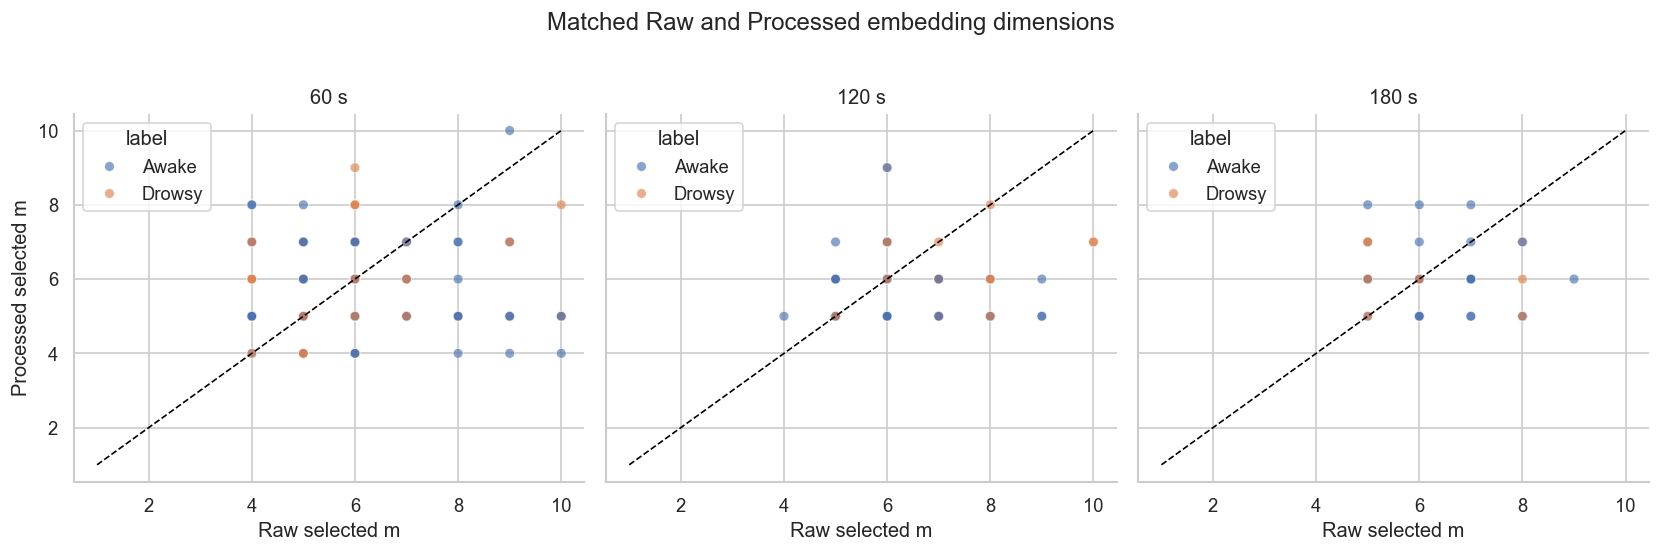

In [16]:
figure, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharex=True, sharey=True)
for axis, window_size in zip(axes, WINDOW_SIZES):
    subset = representation_pairs[
        representation_pairs["window_size_s"] == window_size
    ]
    sns.scatterplot(
        data=subset,
        x="selected_m_raw",
        y="selected_m_processed",
        hue="label",
        alpha=0.65,
        s=34,
        ax=axis,
    )
    axis.plot(
        [1, MAX_M],
        [1, MAX_M],
        color="black",
        linestyle="--",
        linewidth=1,
    )
    axis.set_title(f"{window_size} s")
    axis.set_xlabel("Raw selected m")
    axis.set_ylabel(
        "Processed selected m" if window_size == 60 else ""
    )

figure.suptitle("Matched Raw and Processed embedding dimensions", y=1.02)
figure.tight_layout()
plt.show()


## Độ ổn định theo kích thước cửa sổ

So sánh được thực hiện trên trung vị cấp phiên cho cùng trạng thái và dạng dữ
liệu.


In [17]:
size_wide = session_summary.pivot_table(
    index=["session", "label", "representation"],
    columns="window_size_s",
    values="median_m",
)

stability_rows = []
for first_size, second_size in ((60, 120), (60, 180), (120, 180)):
    paired = size_wide[[first_size, second_size]].dropna().reset_index()
    for (label, representation), group in paired.groupby(
        ["label", "representation"],
        observed=True,
    ):
        difference = (group[first_size] - group[second_size]).abs()
        stability_rows.append({
            "comparison": f"{first_size} vs {second_size}",
            "label": label,
            "representation": representation,
            "paired_n": len(group),
            "median_abs_difference": difference.median(),
            "iqr_abs_difference": iqr(difference),
            "exact_agreement_pct": 100.0 * (difference == 0).mean(),
            "within_1_dimension_pct": 100.0 * (difference <= 1).mean(),
            "spearman_correlation": safe_spearman(
                group[first_size],
                group[second_size],
            ),
        })

window_stability = pd.DataFrame(stability_rows)
display(window_stability)


,comparison,label,representation,paired_n,median_abs_difference,iqr_abs_difference,exact_agreement_pct,within_1_dimension_pct,spearman_correlation
0,60 vs 120,Awake,Processed,20,0.00,1.000,55.000000,90.000000,0.652625
1,60 vs 120,Awake,Raw,14,0.50,1.625,28.571429,71.428571,0.631735
2,60 vs 120,Drowsy,Processed,20,0.50,1.000,45.000000,80.000000,0.364971
3,60 vs 120,Drowsy,Raw,16,1.00,1.125,18.750000,56.250000,0.123451
4,60 vs 180,Awake,Processed,20,1.00,0.625,25.000000,90.000000,0.713993
5,60 vs 180,Awake,Raw,14,0.75,1.000,35.714286,85.714286,0.605672
6,60 vs 180,Drowsy,Processed,17,1.00,0.500,17.647059,88.235294,0.592909
7,60 vs 180,Drowsy,Raw,10,0.50,1.000,40.000000,90.000000,0.693260
8,120 vs 180,Awake,Processed,20,0.25,1.000,50.000000,95.000000,0.591036
9,120 vs 180,Awake,Raw,12,0.50,0.625,25.000000,83.333333,0.706568


## Diagnostic FNN curves

Các cửa sổ được chọn có hệ thống để đại diện cho `m` thấp, trung vị, cao,
failure, khác biệt Raw–Processed và khác biệt Awake–Drowsy.


,selection,session,window_id,window_size_s,label,representation,selected_m
0,Low selected m,sample_1.csv,24,60,Drowsy,Processed,4.0
1,Median selected m,sample_25.csv,2,180,Awake,Processed,6.0
2,High selected m,sample_10.csv,16,120,Drowsy,Raw,10.0
3,selected_m=None,sample_4.csv,1,60,Awake,Raw,NaN
4,Raw-Processed pair: Raw,sample_15.csv,12,60,Awake,Raw,10.0
5,Raw-Processed pair: Processed,sample_15.csv,12,60,Awake,Processed,4.0
6,Awake-Drowsy pair: Awake,sample_15.csv,1,120,Awake,Processed,6.0
7,Awake-Drowsy pair: Drowsy,sample_15.csv,13,120,Drowsy,Processed,10.0


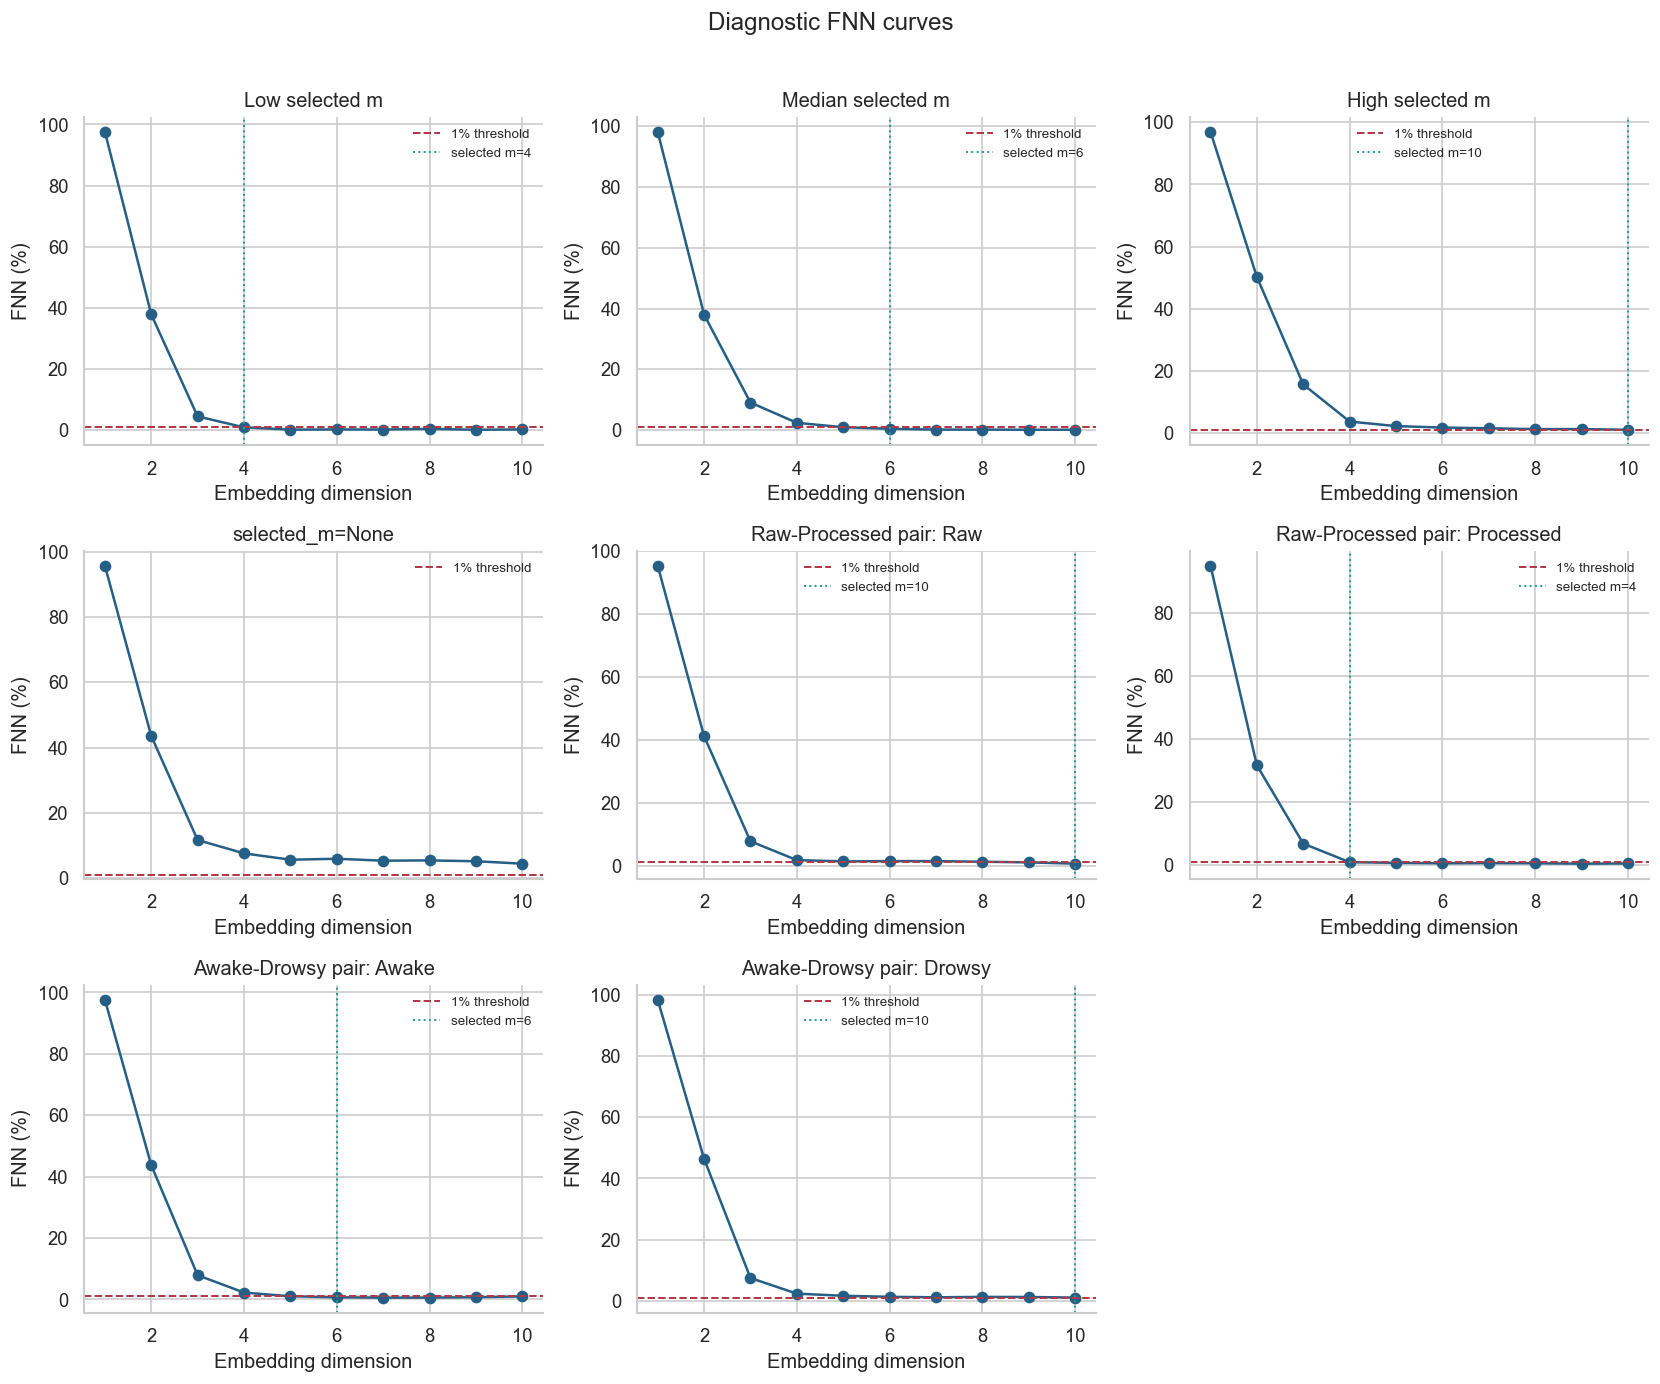

In [18]:
DIAGNOSTIC_KEYS = [
    "session",
    "window_id",
    "window_size_s",
    "label",
    "representation",
]


def append_diagnostic(rows, selection, row):
    "Append one diagnostic row unless it is duplicated."
    if row is None:
        return
    record = row.to_dict()
    key = tuple(record[name] for name in DIAGNOSTIC_KEYS)
    existing = {
        tuple(item[name] for name in DIAGNOSTIC_KEYS)
        for item in rows
    }
    if key not in existing:
        record["selection"] = selection
        rows.append(record)


diagnostic_rows = []
ordered_found = found_results.sort_values("selected_m")
append_diagnostic(
    diagnostic_rows,
    "Low selected m",
    ordered_found.iloc[0],
)
median_m = ordered_found["selected_m"].median()
median_index = (
    ordered_found["selected_m"] - median_m
).abs().idxmin()
append_diagnostic(
    diagnostic_rows,
    "Median selected m",
    ordered_found.loc[median_index],
)
append_diagnostic(
    diagnostic_rows,
    "High selected m",
    ordered_found.iloc[-1],
)

missing_m = fnn_results[~fnn_results["m_found"]]
append_diagnostic(
    diagnostic_rows,
    "selected_m=None",
    None if missing_m.empty else missing_m.iloc[0],
)

if not representation_pairs.empty:
    pair = representation_pairs.loc[
        representation_pairs["delta_m"].abs().idxmax()
    ]
    pair_filter = (
        (fnn_results["session"] == pair["session"])
        & (fnn_results["window_id"] == pair["window_id"])
        & (fnn_results["window_size_s"] == pair["window_size_s"])
        & (fnn_results["label"] == pair["label"])
    )
    for representation in ("Raw", "Processed"):
        row = fnn_results[
            pair_filter
            & (fnn_results["representation"] == representation)
        ].iloc[0]
        append_diagnostic(
            diagnostic_rows,
            f"Raw-Processed pair: {representation}",
            row,
        )

if not state_pairs.empty:
    state_pair = state_pairs.loc[state_pairs["delta_m"].abs().idxmax()]
    for label in ("Awake", "Drowsy"):
        state_filter = (
            (fnn_results["session"] == state_pair["session"])
            & (
                fnn_results["window_size_s"]
                == state_pair["window_size_s"]
            )
            & (
                fnn_results["representation"]
                == state_pair["representation"]
            )
            & (fnn_results["label"] == label)
            & fnn_results["m_found"]
        )
        candidates = fnn_results[state_filter]
        target = state_pair[label]
        if not candidates.empty:
            row_index = (
                candidates["selected_m"] - target
            ).abs().idxmin()
            append_diagnostic(
                diagnostic_rows,
                f"Awake-Drowsy pair: {label}",
                candidates.loc[row_index],
            )

diagnostic_selection = pd.DataFrame(diagnostic_rows)
display(diagnostic_selection[["selection", *DIAGNOSTIC_KEYS, "selected_m"]])

plot_rows = int(np.ceil(len(diagnostic_selection) / 3))
figure, axes = plt.subplots(
    plot_rows,
    3,
    figsize=(14, 3.8 * plot_rows),
    squeeze=False,
)
for axis, (_, row) in zip(axes.flat, diagnostic_selection.iterrows()):
    curve_filter = np.ones(len(fnn_curves), dtype=bool)
    for key in DIAGNOSTIC_KEYS:
        curve_filter &= fnn_curves[key].eq(row[key]).to_numpy()
    curve = fnn_curves[curve_filter]
    axis.plot(
        curve["dimension"],
        curve["fnn_percent"],
        marker="o",
        color="#255f85",
    )
    axis.axhline(
        FNN_THRESHOLD,
        color="#b23a48",
        linestyle="--",
        linewidth=1.2,
        label="1% threshold",
    )
    if row["m_found"]:
        axis.axvline(
            row["selected_m"],
            color="#2a9d8f",
            linestyle=":",
            linewidth=1.2,
            label=f"selected m={int(row['selected_m'])}",
        )
    axis.set_title(row["selection"])
    axis.set_xlabel("Embedding dimension")
    axis.set_ylabel("FNN (%)")
    axis.legend(frameon=False, fontsize=8)

for axis in axes.flat[len(diagnostic_selection):]:
    axis.remove()

figure.suptitle("Diagnostic FNN curves", y=1.01)
figure.tight_layout()
plt.show()


# FNN Decision-Threshold Sensitivity Audit

Phần này triển khai `STEP3B1_FNN_SENSITIVITY_AUDIT.md`. Toàn bộ phân
tích là hậu xử lý của `fnn_curves.csv`; nearest neighbors không được
tính lại. Các threshold `1–5%` chỉ thay đổi quy tắc chọn dimension.


In [3]:
THRESHOLDS = (1.0, 2.0, 3.0, 4.0, 5.0)
from matplotlib.lines import Line2D

THRESHOLD_DIR = PROJECT_ROOT / "phase1" / "results" / "fnn_threshold"
THRESHOLD_FIGURE_DIR = THRESHOLD_DIR / "figures"
THRESHOLD_DIR.mkdir(parents=True, exist_ok=True)
THRESHOLD_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

CURVE_KEYS = [
    "session",
    "window_id",
    "window_size_s",
    "label",
    "representation",
]


def selected_summary(data, group_columns):
    "Summarize threshold-specific selected dimensions."
    rows = []
    grouper = group_columns[0] if len(group_columns) == 1 else group_columns
    for key, group in data.groupby(grouper, observed=True):
        keys = key if isinstance(key, tuple) else (key,)
        found = group.loc[group["m_found"], "selected_m"]
        rows.append({
            **dict(zip(group_columns, keys)),
            "n_windows": len(group),
            "n_m_found": int(group["m_found"].sum()),
            "m_found_rate_pct": 100.0 * group["m_found"].mean(),
            "median_m": found.median(),
            "iqr_m": iqr(found),
            "mode_m": first_mode(found),
            "q10_m": found.quantile(0.10),
            "q25_m": found.quantile(0.25),
            "q50_m": found.quantile(0.50),
            "q75_m": found.quantile(0.75),
            "q90_m": found.quantile(0.90),
            "min_m": found.min(),
            "max_m": found.max(),
            "median_min_fnn_pct": group[
                "min_fnn_percent"
            ].median(),
        })
    return pd.DataFrame(rows)


def save_figure(figure, name, rect=None):
    "Save one publication-ready figure."
    figure.tight_layout(rect=rect)
    figure.savefig(
        THRESHOLD_FIGURE_DIR / name,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## Experiment 0 — Data integrity


In [4]:
threshold_curves = pd.read_csv(CURVE_RESULTS_PATH)
expected_dimensions = tuple(range(1, MAX_M + 1))
curve_groups = threshold_curves.groupby(CURVE_KEYS, observed=True)
dimension_sets = curve_groups["dimension"].agg(
    lambda values: tuple(sorted(values))
)

duplicate_count = int(threshold_curves.duplicated(
    [*CURVE_KEYS, "dimension"]
).sum())
invalid_fnn_count = int((
    ~np.isfinite(threshold_curves["fnn_percent"])
    | ~threshold_curves["fnn_percent"].between(0.0, 100.0)
).sum())
invalid_valid_count = int((
    ~np.isfinite(threshold_curves["valid_count"])
    | threshold_curves["valid_count"].le(0)
).sum())
ordered_curves = threshold_curves.sort_values(
    [*CURVE_KEYS, "dimension"]
)
valid_count_diff = ordered_curves.groupby(
    CURVE_KEYS,
    observed=True,
)["valid_count"].diff()
valid_count_increases = int(valid_count_diff.gt(0).sum())
missing_dimension_windows = int(
    dimension_sets.map(
        lambda dimensions: dimensions != expected_dimensions
    ).sum()
)

integrity = pd.DataFrame({
    "metric": [
        "n_curve_rows",
        "n_unique_windows",
        "n_sessions",
        "missing_dimension_windows",
        "duplicate_rows",
        "invalid_fnn_percent",
        "invalid_valid_count",
        "valid_count_increase_steps",
    ],
    "value": [
        len(threshold_curves),
        len(dimension_sets),
        threshold_curves["session"].nunique(),
        missing_dimension_windows,
        duplicate_count,
        invalid_fnn_count,
        invalid_valid_count,
        valid_count_increases,
    ],
})
coverage = pd.concat(
    [
        threshold_curves.drop_duplicates(CURVE_KEYS)
        .groupby(column, observed=True)
        .size()
        .rename("n_windows")
        .reset_index()
        .assign(stratum=column)
        .rename(columns={column: "value"})
        for column in (
            "window_size_s",
            "label",
            "representation",
        )
    ],
    ignore_index=True,
)

assert missing_dimension_windows == 0
assert duplicate_count == 0
assert invalid_fnn_count == 0
assert invalid_valid_count == 0
assert set(threshold_curves["window_size_s"]) == {60, 120, 180}
assert set(threshold_curves["label"]) == {"Awake", "Drowsy"}
assert set(threshold_curves["representation"]) == {
    "Raw",
    "Processed",
}

display(integrity.style.hide(axis="index"))
display(coverage.style.hide(axis="index"))
display(Markdown(
    "**PASS.** FNN curves đầy đủ và nhất quán cho toàn bộ "
    "window-representation; threshold sensitivity có thể thực hiện "
    "hoàn toàn bằng hậu xử lý."
))


metric,value
n_curve_rows,29420
n_unique_windows,2942
n_sessions,20
missing_dimension_windows,0
duplicate_rows,0
invalid_fnn_percent,0
invalid_valid_count,0
valid_count_increase_steps,0


value,n_windows,stratum
60,1718,window_size_s
120,768,window_size_s
180,456,window_size_s
Awake,1968,label
Drowsy,974,label
Processed,1544,representation
Raw,1398,representation


**PASS.** FNN curves đầy đủ và nhất quán cho toàn bộ window-representation; threshold sensitivity có thể thực hiện hoàn toàn bằng hậu xử lý.

## Experiment 1 — Threshold-specific window results


In [5]:
threshold_rows = []
for key, group in curve_groups:
    group = group.sort_values("dimension")
    minimum_fnn = group["fnn_percent"].min()
    for threshold in THRESHOLDS:
        passing = group[group["fnn_percent"] <= threshold]
        selected = None if passing.empty else passing.iloc[0]
        threshold_rows.append({
            **dict(zip(CURVE_KEYS, key)),
            "threshold_pct": threshold,
            "selected_m": (
                np.nan
                if selected is None
                else int(selected["dimension"])
            ),
            "m_found": selected is not None,
            "min_fnn_percent": minimum_fnn,
            "fnn_at_selected_m": (
                np.nan
                if selected is None
                else selected["fnn_percent"]
            ),
            "valid_count_at_selected_m": (
                np.nan
                if selected is None
                else int(selected["valid_count"])
            ),
        })

threshold_results = pd.DataFrame(threshold_rows)
threshold_results.to_csv(
    THRESHOLD_DIR / "fnn_threshold_window_results.csv",
    index=False,
)
selected_wide = threshold_results.pivot(
    index=CURVE_KEYS,
    columns="threshold_pct",
    values="selected_m",
)
found_wide = threshold_results.pivot(
    index=CURVE_KEYS,
    columns="threshold_pct",
    values="m_found",
)
monotonic_selection_errors = 0
monotonic_found_errors = 0
for low, high in zip(THRESHOLDS[:-1], THRESHOLDS[1:]):
    comparable = selected_wide[[low, high]].dropna()
    monotonic_selection_errors += int(
        comparable[high].gt(comparable[low]).sum()
    )
    monotonic_found_errors += int(
        (found_wide[low] & ~found_wide[high]).sum()
    )

assert len(threshold_results) == len(dimension_sets) * len(THRESHOLDS)
assert monotonic_selection_errors == 0
assert monotonic_found_errors == 0
print(f"Rows: {len(threshold_results):,}")
print(f"Selection monotonic errors: {monotonic_selection_errors}")
print(f"Found monotonic errors: {monotonic_found_errors}")
display(threshold_results.head())


Rows: 14,710
Selection monotonic errors: 0
Found monotonic errors: 0


,session,window_id,window_size_s,label,representation,threshold_pct,selected_m,m_found,min_fnn_percent,fnn_at_selected_m,valid_count_at_selected_m
0,sample_1.csv,1,60,Awake,Processed,1.0,5.0,True,0.06812,0.337838,2960.0
1,sample_1.csv,1,60,Awake,Processed,2.0,5.0,True,0.06812,0.337838,2960.0
2,sample_1.csv,1,60,Awake,Processed,3.0,4.0,True,0.06812,2.055256,2968.0
3,sample_1.csv,1,60,Awake,Processed,4.0,4.0,True,0.06812,2.055256,2968.0
4,sample_1.csv,1,60,Awake,Processed,5.0,4.0,True,0.06812,2.055256,2968.0


## Experiments 2–3 — Global and representation trade-off


threshold_pct,n_windows,n_m_found,m_found_rate_pct,median_m,iqr_m,mode_m,q10_m,q25_m,q50_m,q75_m,q90_m,min_m,max_m,median_min_fnn_pct
1.000000,2942,1404,47.722638,6.000000,2.000000,6.000000,5.000000,5.000000,6.000000,7.000000,8.000000,4.000000,10.000000,1.028738
2.000000,2942,2274,77.294358,5.000000,1.000000,5.000000,4.000000,5.000000,5.000000,6.000000,6.000000,3.000000,10.000000,1.028738
3.000000,2942,2737,93.031951,4.000000,1.000000,4.000000,4.000000,4.000000,4.000000,5.000000,6.000000,3.000000,10.000000,1.028738
4.000000,2942,2916,99.116247,4.000000,1.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,3.000000,10.000000,1.028738
5.000000,2942,2941,99.966010,4.000000,0.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,3.000000,10.000000,1.028738


threshold_pct,representation,n_windows,n_m_found,m_found_rate_pct,median_m,iqr_m,mode_m,q10_m,q25_m,q50_m,q75_m,q90_m,min_m,max_m,median_min_fnn_pct
1.000000,Processed,1544,1075,69.624352,6.000000,2.000000,6.000000,5.000000,5.000000,6.000000,7.000000,8.000000,4.000000,10.000000,0.741240
1.000000,Raw,1398,329,23.533619,6.000000,2.000000,6.000000,5.000000,5.000000,6.000000,7.000000,8.200000,4.000000,10.000000,1.904762
2.000000,Processed,1544,1515,98.121762,5.000000,1.000000,5.000000,4.000000,4.000000,5.000000,5.000000,6.000000,4.000000,9.000000,0.741240
2.000000,Raw,1398,759,54.291845,6.000000,1.000000,5.000000,4.000000,5.000000,6.000000,6.000000,8.000000,3.000000,10.000000,1.904762
3.000000,Processed,1544,1544,100.000000,4.000000,1.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,6.000000,0.741240
3.000000,Raw,1398,1193,85.336195,5.000000,2.000000,5.000000,4.000000,4.000000,5.000000,6.000000,8.000000,3.000000,10.000000,1.904762
4.000000,Processed,1544,1544,100.000000,4.000000,0.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,0.741240
4.000000,Raw,1398,1372,98.140200,5.000000,1.000000,4.000000,4.000000,4.000000,5.000000,5.000000,6.000000,3.000000,10.000000,1.904762
5.000000,Processed,1544,1544,100.000000,4.000000,0.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,0.741240
5.000000,Raw,1398,1397,99.928469,4.000000,1.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,3.000000,10.000000,1.904762


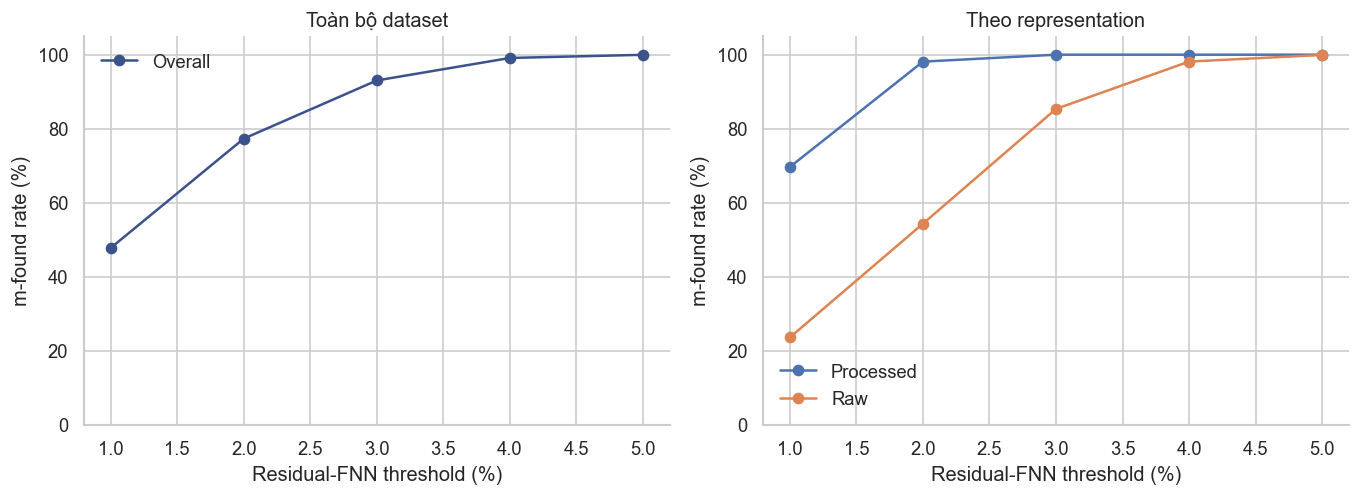

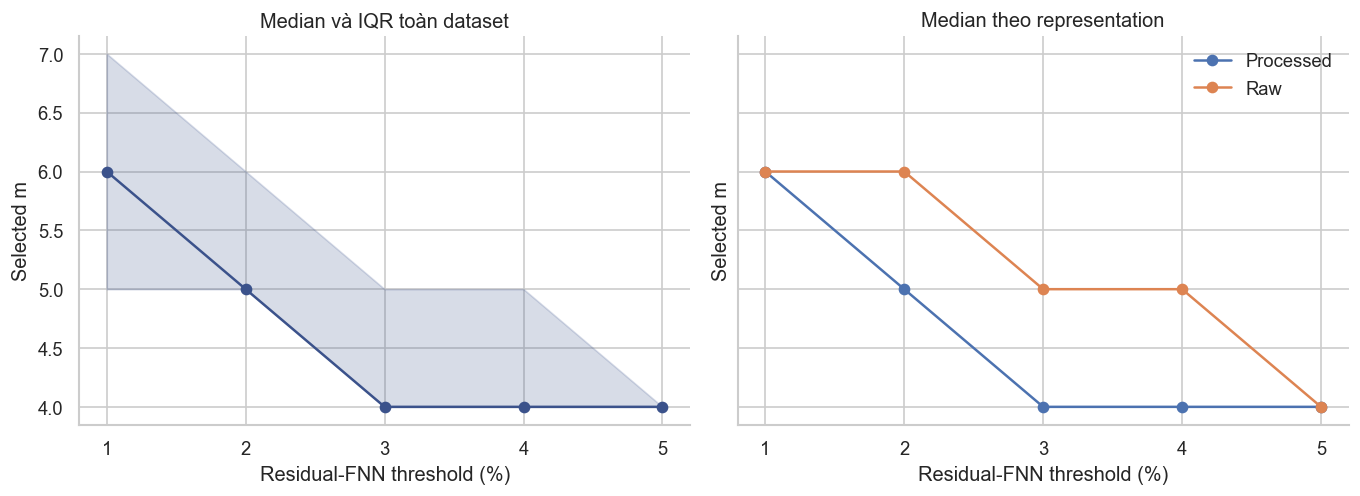

In [6]:
overall_summary = selected_summary(
    threshold_results,
    ["threshold_pct"],
)
representation_summary = selected_summary(
    threshold_results,
    ["threshold_pct", "representation"],
)
overall_summary.to_csv(
    THRESHOLD_DIR / "fnn_threshold_overall_summary.csv",
    index=False,
)
representation_summary.to_csv(
    THRESHOLD_DIR / "fnn_threshold_representation_summary.csv",
    index=False,
)
display(overall_summary.style.hide(axis="index"))
display(representation_summary.style.hide(axis="index"))

figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
axes[0].plot(
    overall_summary["threshold_pct"],
    overall_summary["m_found_rate_pct"],
    marker="o",
    color="#3b528b",
    label="Overall",
)
for representation, group in representation_summary.groupby(
    "representation",
    observed=True,
):
    axes[1].plot(
        group["threshold_pct"],
        group["m_found_rate_pct"],
        marker="o",
        label=representation,
    )
for axis in axes:
    axis.set_xlabel("Residual-FNN threshold (%)")
    axis.set_ylabel("m-found rate (%)")
    axis.set_ylim(0, 105)
    axis.legend(frameon=False)
axes[0].set_title("Toàn bộ dataset")
axes[1].set_title("Theo representation")
save_figure(figure, "threshold_vs_found_rate.png")

figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), sharey=True)
axes[0].plot(
    overall_summary["threshold_pct"],
    overall_summary["median_m"],
    marker="o",
    color="#3b528b",
)
axes[0].fill_between(
    overall_summary["threshold_pct"],
    overall_summary["q25_m"],
    overall_summary["q75_m"],
    color="#3b528b",
    alpha=0.20,
)
for representation, group in representation_summary.groupby(
    "representation",
    observed=True,
):
    axes[1].plot(
        group["threshold_pct"],
        group["median_m"],
        marker="o",
        label=representation,
    )
for axis in axes:
    axis.set_xlabel("Residual-FNN threshold (%)")
    axis.set_ylabel("Selected m")
    axis.set_xticks(THRESHOLDS)
axes[0].set_title("Median và IQR toàn dataset")
axes[1].set_title("Median theo representation")
axes[1].legend(frameon=False)
save_figure(figure, "threshold_vs_selected_m.png")


## Experiment 4 — Awake–Drowsy robustness


threshold_pct,window_size_s,representation,n_paired_sessions,median_delta_m,iqr_delta_m,drowsy_higher_pct,equal_pct,drowsy_lower_pct
1.000000,60,Processed,20,0.000000,1.125000,40.000000,30.000000,30.000000
1.000000,60,Raw,18,-0.500000,1.875000,38.888889,5.555556,55.555556
1.000000,120,Processed,20,0.000000,1.000000,45.000000,35.000000,20.000000
1.000000,120,Raw,12,0.000000,1.625000,41.666667,16.666667,41.666667
1.000000,180,Processed,17,0.000000,1.500000,47.058824,23.529412,29.411765
1.000000,180,Raw,9,0.000000,1.000000,22.222222,33.333333,44.444444
2.000000,60,Processed,20,0.000000,0.000000,15.000000,75.000000,10.000000
2.000000,60,Raw,20,0.000000,1.000000,20.000000,35.000000,45.000000
2.000000,120,Processed,20,0.000000,0.000000,10.000000,80.000000,10.000000
2.000000,120,Raw,19,-0.500000,1.000000,15.789474,26.315789,57.894737


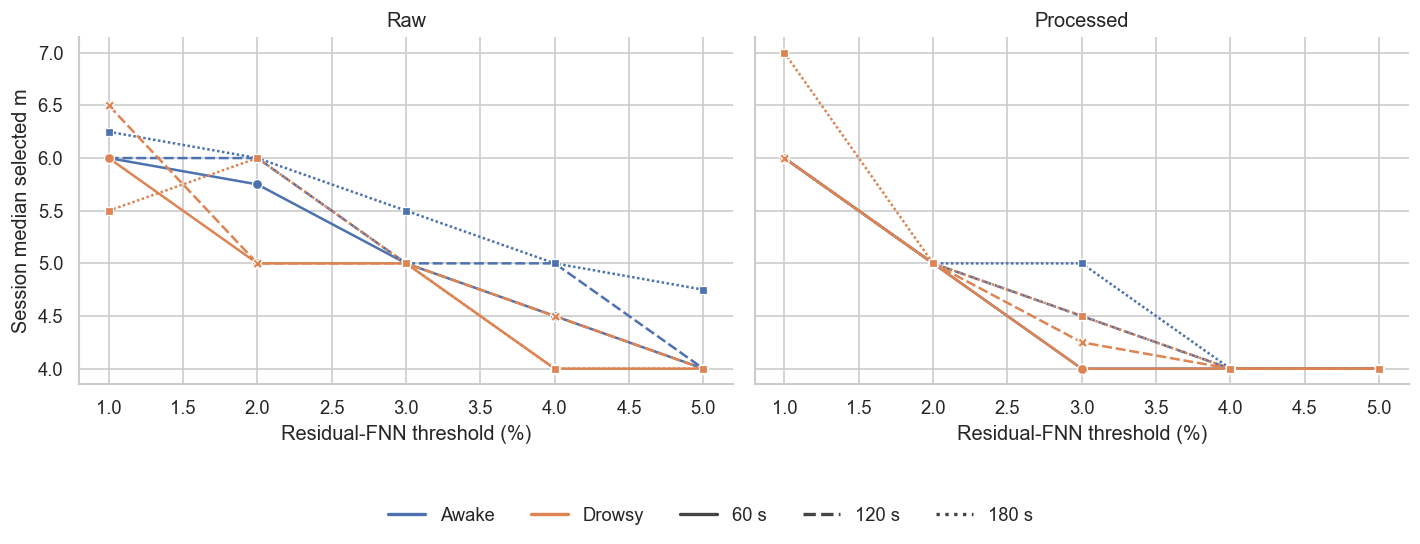

In [7]:
state_summary = selected_summary(
    threshold_results,
    [
        "threshold_pct",
        "window_size_s",
        "representation",
        "label",
    ],
)
state_summary.to_csv(
    THRESHOLD_DIR / "fnn_threshold_state_summary.csv",
    index=False,
)
session_summary_threshold = selected_summary(
    threshold_results,
    [
        "session",
        "threshold_pct",
        "window_size_s",
        "label",
        "representation",
    ],
)
session_summary_threshold.to_csv(
    THRESHOLD_DIR / "fnn_threshold_session_summary.csv",
    index=False,
)
state_pairs = (
    session_summary_threshold.pivot_table(
        index=[
            "session",
            "threshold_pct",
            "window_size_s",
            "representation",
        ],
        columns="label",
        values="median_m",
    )
    .dropna(subset=["Awake", "Drowsy"])
    .reset_index()
)
state_pairs["delta_m"] = state_pairs["Drowsy"] - state_pairs["Awake"]
state_pair_rows = []
for key, group in state_pairs.groupby(
    ["threshold_pct", "window_size_s", "representation"],
    observed=True,
):
    delta = group["delta_m"]
    state_pair_rows.append({
        "threshold_pct": key[0],
        "window_size_s": key[1],
        "representation": key[2],
        "n_paired_sessions": len(group),
        "median_delta_m": delta.median(),
        "iqr_delta_m": iqr(delta),
        "drowsy_higher_pct": 100.0 * delta.gt(0).mean(),
        "equal_pct": 100.0 * delta.eq(0).mean(),
        "drowsy_lower_pct": 100.0 * delta.lt(0).mean(),
    })
state_pair_summary = pd.DataFrame(state_pair_rows)
display(state_pair_summary.style.hide(axis="index"))

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for axis, representation in zip(axes, ("Raw", "Processed")):
    subset = session_summary_threshold[
        session_summary_threshold["representation"] == representation
    ]
    sns.lineplot(
        data=subset,
        x="threshold_pct",
        y="median_m",
        hue="label",
        style="window_size_s",
        estimator="median",
        errorbar=None,
        markers=True,
        legend=False,
        ax=axis,
    )
    axis.set_title(representation)
    axis.set_xlabel("Residual-FNN threshold (%)")
    axis.set_ylabel("Session median selected m")
state_handles = [
    Line2D([0], [0], color=color, linewidth=2)
    for color in sns.color_palette()[:2]
]
size_handles = [
    Line2D(
        [0],
        [0],
        color="#444444",
        linestyle=style,
        linewidth=2,
    )
    for style in ("-", "--", ":")
]
figure.legend(
    [*state_handles, *size_handles],
    ["Awake", "Drowsy", "60 s", "120 s", "180 s"],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=5,
    frameon=False,
)
save_figure(
    figure,
    "selected_m_by_state.png",
    rect=(0.0, 0.12, 1.0, 1.0),
)


## Experiment 5 — Window-length robustness


threshold_pct,representation,comparison,n_pairs,median_abs_delta_m,iqr_abs_delta_m,within_1_pct,spearman_r
1.000000,Processed,60 vs 120,40,0.250000,1.000000,85.000000,0.492709
1.000000,Raw,60 vs 120,30,1.000000,1.375000,63.333333,0.394751
2.000000,Processed,60 vs 120,40,0.000000,0.500000,100.000000,0.502830
2.000000,Raw,60 vs 120,39,0.500000,1.000000,92.307692,0.571499
3.000000,Processed,60 vs 120,40,0.000000,1.000000,100.000000,0.274114
3.000000,Raw,60 vs 120,39,0.000000,0.750000,94.871795,0.844490
4.000000,Processed,60 vs 120,40,0.000000,0.000000,100.000000,nan
4.000000,Raw,60 vs 120,39,0.000000,0.500000,97.435897,0.844072
5.000000,Processed,60 vs 120,40,0.000000,0.000000,100.000000,nan
5.000000,Raw,60 vs 120,39,0.000000,0.750000,100.000000,0.552939


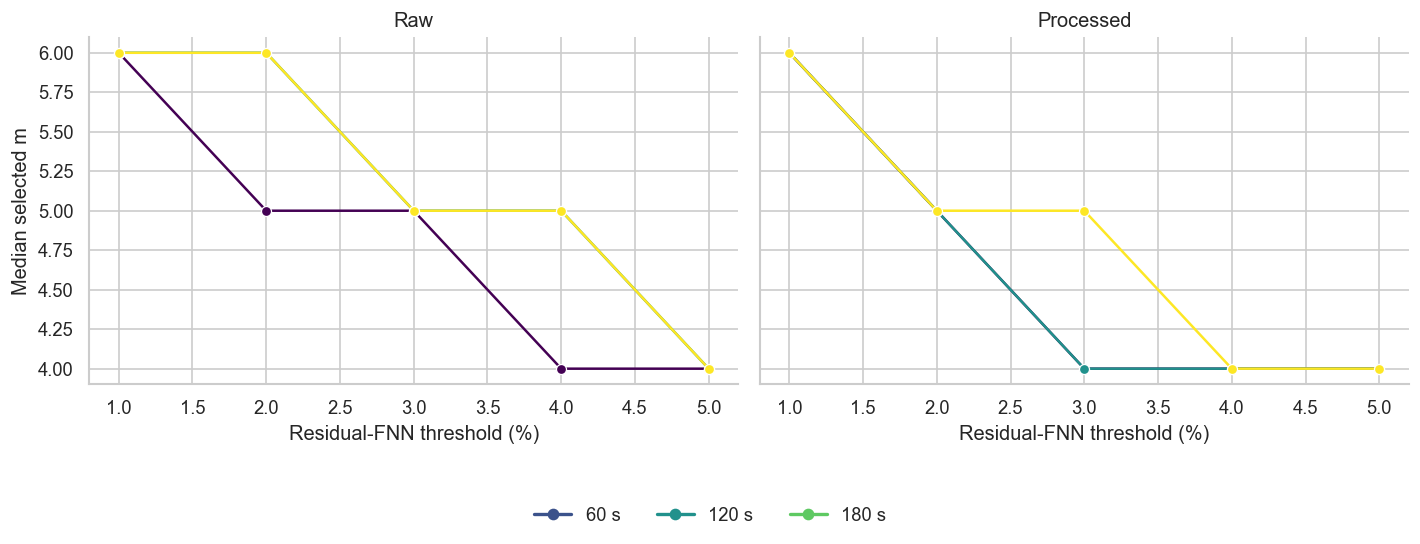

In [8]:
window_size_summary = selected_summary(
    threshold_results,
    ["threshold_pct", "representation", "window_size_s"],
)
window_size_summary.to_csv(
    THRESHOLD_DIR / "fnn_threshold_window_size_summary.csv",
    index=False,
)
size_wide_threshold = session_summary_threshold.pivot_table(
    index=[
        "session",
        "threshold_pct",
        "label",
        "representation",
    ],
    columns="window_size_s",
    values="median_m",
).reset_index()
size_pair_rows = []
for size_a, size_b in ((60, 120), (60, 180), (120, 180)):
    pair = size_wide_threshold.dropna(subset=[size_a, size_b]).copy()
    pair["abs_delta"] = (pair[size_b] - pair[size_a]).abs()
    for key, group in pair.groupby(
        ["threshold_pct", "representation"],
        observed=True,
    ):
        size_pair_rows.append({
            "threshold_pct": key[0],
            "representation": key[1],
            "comparison": f"{size_a} vs {size_b}",
            "n_pairs": len(group),
            "median_abs_delta_m": group["abs_delta"].median(),
            "iqr_abs_delta_m": iqr(group["abs_delta"]),
            "within_1_pct": 100.0 * group["abs_delta"].le(1).mean(),
            "spearman_r": safe_spearman(group[size_a], group[size_b]),
        })
size_pair_summary = pd.DataFrame(size_pair_rows)
display(size_pair_summary.style.hide(axis="index"))

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for axis, representation in zip(axes, ("Raw", "Processed")):
    subset = window_size_summary[
        window_size_summary["representation"] == representation
    ]
    sns.lineplot(
        data=subset,
        x="threshold_pct",
        y="median_m",
        hue="window_size_s",
        marker="o",
        palette="viridis",
        legend=False,
        ax=axis,
    )
    axis.set_title(representation)
    axis.set_xlabel("Residual-FNN threshold (%)")
    axis.set_ylabel("Median selected m")
window_handles = [
    Line2D(
        [0],
        [0],
        color=color,
        marker="o",
        linewidth=2,
    )
    for color in sns.color_palette("viridis", 3)
]
figure.legend(
    window_handles,
    ["60 s", "120 s", "180 s"],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    frameon=False,
)
save_figure(
    figure,
    "selected_m_by_window_size.png",
    rect=(0.0, 0.12, 1.0, 1.0),
)


## Experiment 6 — Threshold agreement


In [9]:
comparisons = sorted({
    *(zip(THRESHOLDS[:-1], THRESHOLDS[1:])),
    *((THRESHOLDS[0], value) for value in THRESHOLDS[1:]),
})
agreement_rows = []
for scope in ("Overall", "Raw", "Processed"):
    scoped = threshold_results
    if scope != "Overall":
        scoped = scoped[scoped["representation"] == scope]
    for threshold_a, threshold_b in comparisons:
        left = scoped[scoped["threshold_pct"] == threshold_a]
        right = scoped[scoped["threshold_pct"] == threshold_b]
        paired = left.merge(
            right,
            on=CURVE_KEYS,
            suffixes=("_a", "_b"),
            validate="one_to_one",
        )
        comparable = paired[
            paired["m_found_a"] & paired["m_found_b"]
        ].copy()
        delta = (
            comparable["selected_m_b"]
            - comparable["selected_m_a"]
        ).abs()
        newly_found = ~paired["m_found_a"] & paired["m_found_b"]
        agreement_rows.append({
            "scope": scope,
            "threshold_a": threshold_a,
            "threshold_b": threshold_b,
            "n_windows": len(paired),
            "n_comparable": len(comparable),
            "exact_agreement_pct": 100.0 * delta.eq(0).mean(),
            "within_1_dimension_pct": 100.0 * delta.le(1).mean(),
            "within_2_dimensions_pct": 100.0 * delta.le(2).mean(),
            "median_abs_delta_m": delta.median(),
            "iqr_abs_delta_m": iqr(delta),
            "newly_found_n": int(newly_found.sum()),
            "newly_found_pct": 100.0 * newly_found.mean(),
        })
threshold_agreement = pd.DataFrame(agreement_rows)
threshold_agreement.to_csv(
    THRESHOLD_DIR / "fnn_threshold_agreement.csv",
    index=False,
)
display(threshold_agreement.style.hide(axis="index"))


scope,threshold_a,threshold_b,n_windows,n_comparable,exact_agreement_pct,within_1_dimension_pct,within_2_dimensions_pct,median_abs_delta_m,iqr_abs_delta_m,newly_found_n,newly_found_pct
Overall,1.000000,2.000000,2942,1404,16.310541,63.390313,85.327635,1.000000,1.000000,870,29.571720
Overall,1.000000,3.000000,2942,1404,6.623932,45.299145,74.572650,2.000000,2.000000,1333,45.309313
Overall,1.000000,4.000000,2942,1404,3.490028,36.039886,69.444444,2.000000,2.000000,1512,51.393610
Overall,1.000000,5.000000,2942,1404,1.780627,30.698006,66.595442,2.000000,2.000000,1537,52.243372
Overall,2.000000,3.000000,2942,2274,44.195251,88.830255,95.822339,1.000000,1.000000,463,15.737593
Overall,3.000000,4.000000,2942,2737,58.531239,91.852393,96.492510,0.000000,1.000000,179,6.084296
Overall,4.000000,5.000000,2942,2916,76.131687,96.502058,98.731139,0.000000,0.000000,25,0.849762
Raw,1.000000,2.000000,1398,329,16.109422,61.398176,82.674772,1.000000,1.000000,430,30.758226
Raw,1.000000,3.000000,1398,329,6.382979,43.768997,72.948328,2.000000,2.000000,864,61.802575
Raw,1.000000,4.000000,1398,329,2.127660,32.522796,66.261398,2.000000,2.000000,1043,74.606581


## Experiment 7 — Residual-FNN plateau


scope,group_value,dimension,n_windows,median_fnn_pct,iqr_fnn_pct,q25_fnn_pct,q75_fnn_pct,q90_fnn_pct,median_delta_to_next,iqr_delta_to_next
representation,Processed,1,1544,96.791444,2.196773,95.836825,98.033598,98.532028,60.530891,9.290547
representation,Processed,2,1544,36.126005,11.394169,31.434316,42.828485,47.777329,28.870013,8.880868
representation,Processed,3,1544,7.594086,2.913575,6.293414,9.206989,10.582398,4.963789,2.254543
representation,Processed,4,1544,2.613941,1.347709,1.954178,3.301887,3.906940,1.138229,0.992996
representation,Processed,5,1544,1.418919,0.792785,0.985738,1.778523,2.163185,0.335274,0.406850
representation,Processed,6,1544,1.016260,0.700181,0.677507,1.377688,1.761518,0.100484,0.336532
representation,Processed,7,1544,0.883152,0.701579,0.543478,1.245058,1.648721,-0.000370,0.237679
representation,Processed,8,1544,0.876011,0.713732,0.512426,1.226158,1.684636,-0.068492,0.268660
representation,Processed,9,1544,0.929659,0.819672,0.546448,1.366120,1.775956,-0.070263,0.289238
representation,Processed,10,1544,1.027397,0.946311,0.560538,1.506849,1.986301,nan,nan


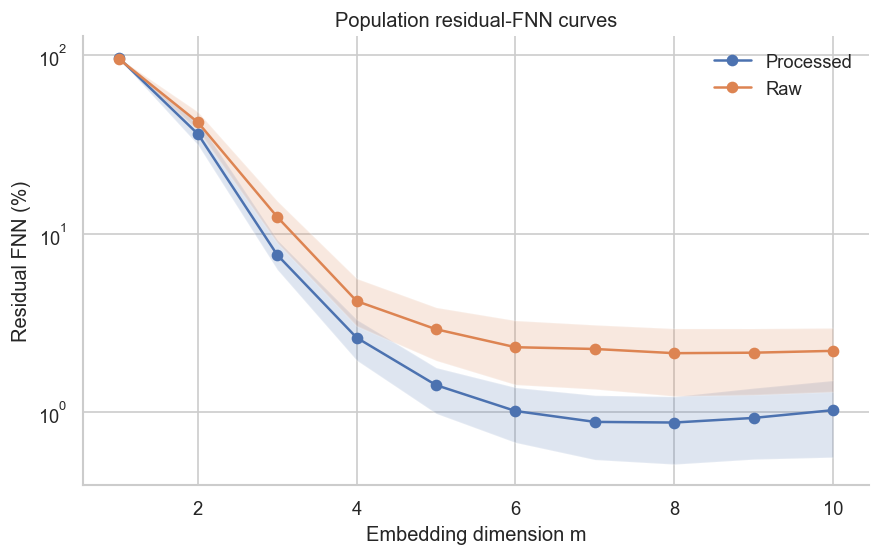

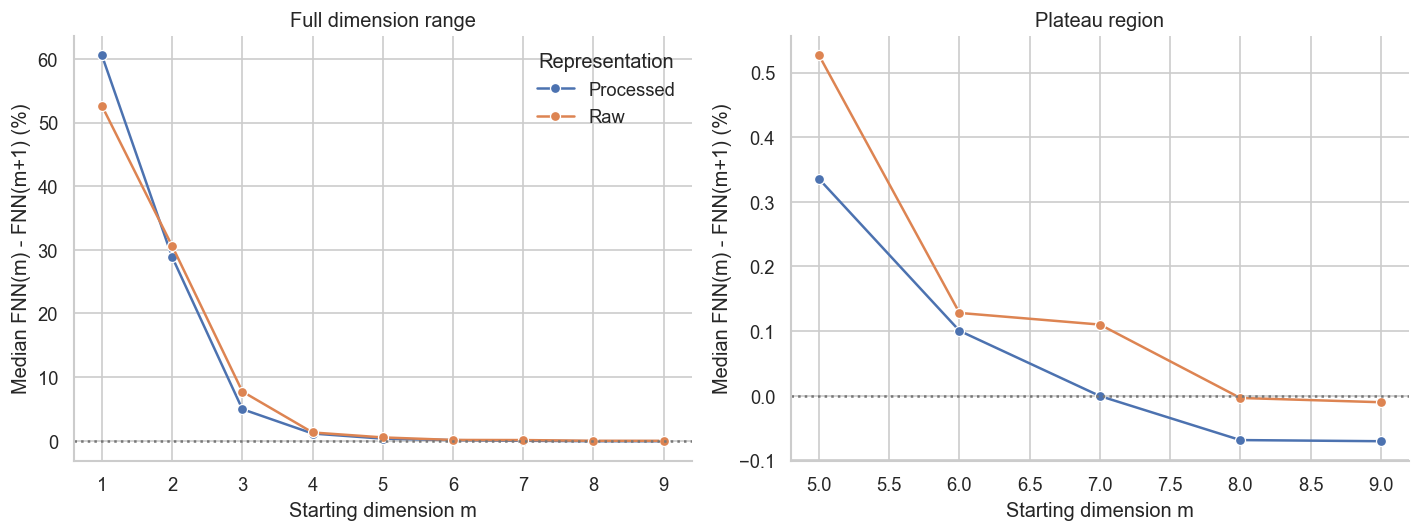

In [10]:
plateau_curves = threshold_curves.sort_values(
    [*CURVE_KEYS, "dimension"]
).copy()
plateau_curves["next_fnn_percent"] = plateau_curves.groupby(
    CURVE_KEYS,
    observed=True,
)["fnn_percent"].shift(-1)
plateau_curves["delta_fnn"] = (
    plateau_curves["fnn_percent"]
    - plateau_curves["next_fnn_percent"]
)


def plateau_table(data, scope, group_column=None):
    "Summarize population FNN curves for one scope."
    columns = ["dimension"]
    if group_column is not None:
        columns.insert(0, group_column)
    rows = []
    for key, group in data.groupby(columns, observed=True):
        keys = key if isinstance(key, tuple) else (key,)
        mapping = dict(zip(columns, keys))
        values = group["fnn_percent"]
        delta = group["delta_fnn"].dropna()
        rows.append({
            "scope": scope,
            "group_value": (
                "All"
                if group_column is None
                else mapping[group_column]
            ),
            "dimension": mapping["dimension"],
            "n_windows": len(group),
            "median_fnn_pct": values.median(),
            "iqr_fnn_pct": iqr(values),
            "q25_fnn_pct": values.quantile(0.25),
            "q75_fnn_pct": values.quantile(0.75),
            "q90_fnn_pct": values.quantile(0.90),
            "median_delta_to_next": delta.median(),
            "iqr_delta_to_next": iqr(delta),
        })
    return pd.DataFrame(rows)


plateau_summary = pd.concat(
    [
        plateau_table(plateau_curves, "Overall"),
        plateau_table(
            plateau_curves,
            "representation",
            "representation",
        ),
        plateau_table(plateau_curves, "state", "label"),
        plateau_table(
            plateau_curves,
            "window_size",
            "window_size_s",
        ),
    ],
    ignore_index=True,
)
plateau_summary.to_csv(
    THRESHOLD_DIR / "fnn_plateau_summary.csv",
    index=False,
)
representation_plateau = plateau_summary[
    plateau_summary["scope"] == "representation"
]
display(representation_plateau.style.hide(axis="index"))

figure, axis = plt.subplots(figsize=(7.5, 4.8))
for representation, group in representation_plateau.groupby(
    "group_value",
    observed=True,
):
    axis.plot(
        group["dimension"],
        group["median_fnn_pct"],
        marker="o",
        label=representation,
    )
    axis.fill_between(
        group["dimension"],
        group["q25_fnn_pct"],
        group["q75_fnn_pct"],
        alpha=0.18,
    )
axis.set_yscale("log")
axis.set_xlabel("Embedding dimension m")
axis.set_ylabel("Residual FNN (%)")
axis.set_title("Population residual-FNN curves")
axis.legend(frameon=False)
save_figure(figure, "fnn_curve_population.png")

figure, axes = plt.subplots(1, 2, figsize=(12, 4.6))
improvement = representation_plateau[
    representation_plateau["dimension"] < MAX_M
]
for axis, subset, title in (
    (axes[0], improvement, "Full dimension range"),
    (
        axes[1],
        improvement[improvement["dimension"] >= 5],
        "Plateau region",
    ),
):
    sns.lineplot(
        data=subset,
        x="dimension",
        y="median_delta_to_next",
        hue="group_value",
        marker="o",
        legend=axis is axes[0],
        ax=axis,
    )
    axis.axhline(0.0, color="#777777", linestyle=":")
    axis.set_xlabel("Starting dimension m")
    axis.set_ylabel("Median FNN(m) - FNN(m+1) (%)")
    axis.set_title(title)
axes[0].legend(title="Representation", frameon=False)
save_figure(figure, "fnn_improvement_curve.png")


## Experiment 8 — Threshold crossing profile


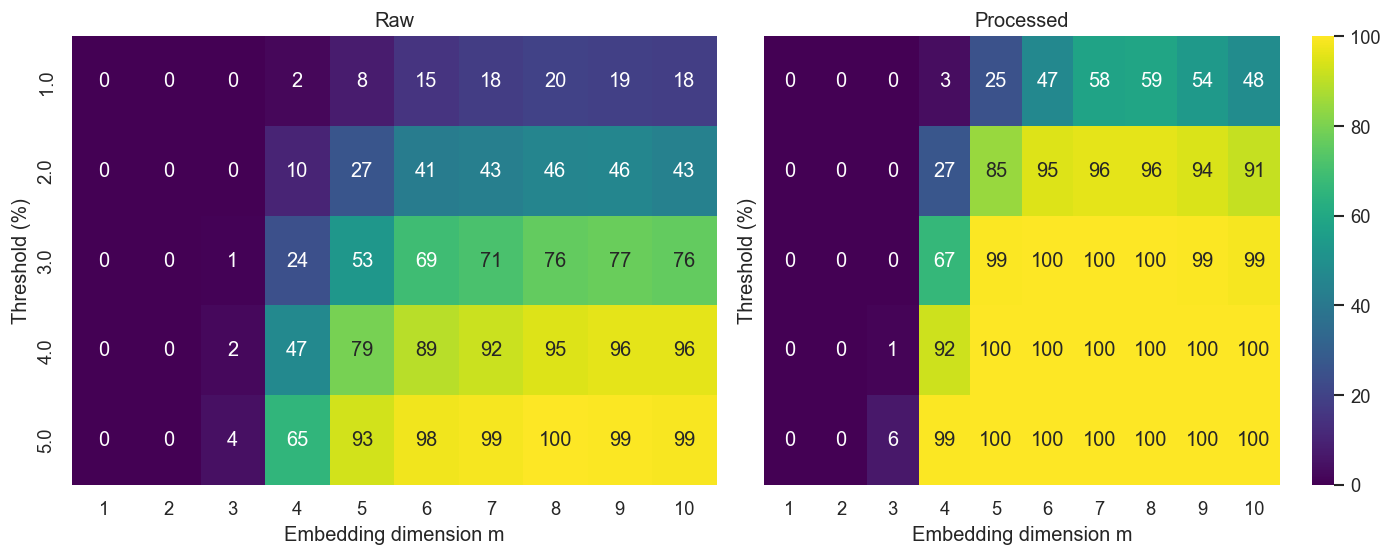

In [11]:
crossing_rows = []
for representation, group in threshold_curves.groupby(
    "representation",
    observed=True,
):
    for dimension, dimension_group in group.groupby(
        "dimension",
        observed=True,
    ):
        for threshold in THRESHOLDS:
            crossing_rows.append({
                "representation": representation,
                "dimension": dimension,
                "threshold_pct": threshold,
                "satisfying_pct": 100.0 * dimension_group[
                    "fnn_percent"
                ].le(threshold).mean(),
            })
crossing_profile = pd.DataFrame(crossing_rows)
figure, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
for axis, representation in zip(axes, ("Raw", "Processed")):
    matrix = crossing_profile[
        crossing_profile["representation"] == representation
    ].pivot(
        index="threshold_pct",
        columns="dimension",
        values="satisfying_pct",
    )
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".0f",
        cmap="viridis",
        vmin=0,
        vmax=100,
        cbar=representation == "Processed",
        ax=axis,
    )
    axis.set_title(representation)
    axis.set_xlabel("Embedding dimension m")
    axis.set_ylabel("Threshold (%)")
save_figure(figure, "threshold_dimension_heatmap.png")


## Experiment 9 — Failure analysis


In [12]:
fnn_at_m10 = threshold_curves[
    threshold_curves["dimension"] == MAX_M
][CURVE_KEYS + ["fnn_percent"]].rename(
    columns={"fnn_percent": "fnn_at_max_m"}
)
failure_data = threshold_results.merge(
    fnn_at_m10,
    on=CURVE_KEYS,
    validate="many_to_one",
)


def failure_table(data, scope, group_column=None):
    "Summarize threshold-crossing failures."
    columns = ["threshold_pct"]
    if group_column is not None:
        columns.append(group_column)
    rows = []
    for key, group in data.groupby(columns, observed=True):
        keys = key if isinstance(key, tuple) else (key,)
        mapping = dict(zip(columns, keys))
        failed = group[~group["m_found"]].copy()
        gap = failed["min_fnn_percent"] - mapping["threshold_pct"]
        rows.append({
            "scope": scope,
            "group_value": (
                "All"
                if group_column is None
                else mapping[group_column]
            ),
            "threshold_pct": mapping["threshold_pct"],
            "n_windows": len(group),
            "n_failed": len(failed),
            "failure_rate_pct": 100.0 * len(failed) / len(group),
            "median_min_fnn_pct": failed[
                "min_fnn_percent"
            ].median(),
            "q25_min_fnn_pct": failed[
                "min_fnn_percent"
            ].quantile(0.25),
            "q75_min_fnn_pct": failed[
                "min_fnn_percent"
            ].quantile(0.75),
            "median_fnn_at_max_m": failed["fnn_at_max_m"].median(),
            "near_threshold_pct": 100.0 * gap.le(1.0).mean(),
            "moderate_pct": 100.0 * gap.between(
                1.0,
                5.0,
                inclusive="right",
            ).mean(),
            "far_pct": 100.0 * gap.gt(5.0).mean(),
        })
    return pd.DataFrame(rows)


failure_summary = pd.concat(
    [
        failure_table(failure_data, "Overall"),
        failure_table(
            failure_data,
            "representation",
            "representation",
        ),
        failure_table(failure_data, "state", "label"),
        failure_table(
            failure_data,
            "window_size",
            "window_size_s",
        ),
        failure_table(failure_data, "session", "session"),
    ],
    ignore_index=True,
)
failure_summary.to_csv(
    THRESHOLD_DIR / "fnn_failure_summary.csv",
    index=False,
)
display(
    failure_summary[
        failure_summary["scope"].isin(["Overall", "representation"])
    ].style.hide(axis="index")
)


scope,group_value,threshold_pct,n_windows,n_failed,failure_rate_pct,median_min_fnn_pct,q25_min_fnn_pct,q75_min_fnn_pct,median_fnn_at_max_m,near_threshold_pct,moderate_pct,far_pct
Overall,All,1.000000,2942,1538,52.277362,1.849315,1.310345,2.551724,2.260274,56.566970,43.433030,0.000000
Overall,All,2.000000,2942,668,22.705642,2.671494,2.304694,3.172414,3.017972,69.311377,30.688623,0.000000
Overall,All,3.000000,2942,205,6.968049,3.467562,3.219178,3.724138,3.694915,87.317073,12.682927,0.000000
Overall,All,4.000000,2942,26,0.883753,4.329948,4.087239,4.431093,4.512566,96.153846,3.846154,0.000000
Overall,All,5.000000,2942,1,0.033990,5.034483,5.034483,5.034483,5.034483,100.000000,0.000000,0.000000
representation,Processed,1.000000,1544,469,30.375648,1.290761,1.110363,1.506849,1.749271,93.816631,6.183369,0.000000
representation,Raw,1.000000,1398,1069,76.466381,2.226721,1.681614,2.837838,2.576271,40.224509,59.775491,0.000000
representation,Processed,2.000000,1544,29,1.878238,2.123288,2.100271,2.297297,2.671233,100.000000,0.000000,0.000000
representation,Raw,2.000000,1398,639,45.708155,2.698145,2.336770,3.186441,3.034390,67.918623,32.081377,0.000000
representation,Processed,3.000000,1544,0,0.000000,nan,nan,nan,nan,nan,nan,nan


## Experiment 10 — Session influence


In [13]:
session_influence = selected_summary(
    threshold_results,
    ["threshold_pct", "session"],
)
session_influence["window_fraction_pct"] = 100.0 * (
    session_influence["n_windows"]
    / session_influence.groupby("threshold_pct")[
        "n_windows"
    ].transform("sum")
)
influence_summary = (
    session_influence.groupby("threshold_pct", observed=True)
    .agg(
        largest_session_contribution_pct=(
            "window_fraction_pct",
            "max",
        ),
        median_windows_per_session=("n_windows", "median"),
        min_windows_per_session=("n_windows", "min"),
        max_windows_per_session=("n_windows", "max"),
        median_session_found_rate_pct=(
            "m_found_rate_pct",
            "median",
        ),
        median_session_m=("median_m", "median"),
    )
    .reset_index()
)
display(influence_summary.style.hide(axis="index"))


threshold_pct,largest_session_contribution_pct,median_windows_per_session,min_windows_per_session,max_windows_per_session,median_session_found_rate_pct,median_session_m
1.000000,6.764106,147.000000,80,199,46.020299,6.000000
2.000000,6.764106,147.000000,80,199,75.773002,5.000000
3.000000,6.764106,147.000000,80,199,93.803608,4.250000
4.000000,6.764106,147.000000,80,199,100.000000,4.000000
5.000000,6.764106,147.000000,80,199,100.000000,4.000000


## Experiment 11 — Integrated trade-off scorecard


In [14]:
scorecard_rows = []
interpretation = {
    1.0: "Strict; low coverage",
    2.0: "Transition region",
    3.0: "Coverage elbow; stable-middle candidate",
    4.0: "High coverage; increasingly permissive",
    5.0: "Near saturation; permissive",
}
for threshold in THRESHOLDS:
    overall = overall_summary[
        overall_summary["threshold_pct"] == threshold
    ].iloc[0]
    by_representation = representation_summary[
        representation_summary["threshold_pct"] == threshold
    ].set_index("representation")
    state_delta = state_pairs[
        state_pairs["threshold_pct"] == threshold
    ]["delta_m"].abs()
    short_window = size_pair_summary[
        (size_pair_summary["threshold_pct"] == threshold)
        & size_pair_summary["comparison"].isin(
            ["60 vs 120", "60 vs 180"]
        )
    ]["median_abs_delta_m"]
    previous = threshold_agreement[
        (threshold_agreement["scope"] == "Overall")
        & threshold_agreement["threshold_b"].eq(threshold)
        & threshold_agreement["threshold_a"].eq(threshold - 1.0)
    ]
    scorecard_rows.append({
        "threshold_pct": threshold,
        "overall_found_rate_pct": overall["m_found_rate_pct"],
        "raw_found_rate_pct": by_representation.loc[
            "Raw",
            "m_found_rate_pct",
        ],
        "processed_found_rate_pct": by_representation.loc[
            "Processed",
            "m_found_rate_pct",
        ],
        "median_m": overall["median_m"],
        "iqr_m": overall["iqr_m"],
        "q90_m": overall["q90_m"],
        "median_abs_state_delta_m": state_delta.median(),
        "median_60_vs_long_delta_m": short_window.median(),
        "raw_processed_median_gap": abs(
            by_representation.loc["Raw", "median_m"]
            - by_representation.loc["Processed", "median_m"]
        ),
        "within_1_vs_previous_pct": (
            np.nan
            if previous.empty
            else previous["within_1_dimension_pct"].iloc[0]
        ),
        "interpretation": interpretation[threshold],
    })
threshold_scorecard = pd.DataFrame(scorecard_rows)
display(threshold_scorecard.style.hide(axis="index"))


threshold_pct,overall_found_rate_pct,raw_found_rate_pct,processed_found_rate_pct,median_m,iqr_m,q90_m,median_abs_state_delta_m,median_60_vs_long_delta_m,raw_processed_median_gap,within_1_vs_previous_pct,interpretation
1.000000,47.722638,23.533619,69.624352,6.000000,2.000000,8.000000,1.000000,0.750000,0.000000,nan,Strict; low coverage
2.000000,77.294358,54.291845,98.121762,5.000000,1.000000,6.000000,0.000000,0.250000,1.000000,63.390313,Transition region
3.000000,93.031951,85.336195,100.000000,4.000000,1.000000,6.000000,0.250000,0.000000,1.000000,88.830255,Coverage elbow; stable-middle candidate
4.000000,99.116247,98.140200,100.000000,4.000000,1.000000,5.000000,0.000000,0.000000,1.000000,91.852393,High coverage; increasingly permissive
5.000000,99.966010,99.928469,100.000000,4.000000,0.000000,5.000000,0.000000,0.000000,0.000000,96.502058,Near saturation; permissive


## Experiment 12 — Final fixed-m evaluation


In [15]:
candidate_rows = []
for candidate_m in (7, 8, 9):
    for representation in ("Raw", "Processed"):
        current = threshold_curves[
            (threshold_curves["dimension"] == candidate_m)
            & (
                threshold_curves["representation"]
                == representation
            )
        ]["fnn_percent"]
        next_values = threshold_curves[
            (threshold_curves["dimension"] == candidate_m + 1)
            & (
                threshold_curves["representation"]
                == representation
            )
        ][CURVE_KEYS + ["fnn_percent"]]
        current_rows = threshold_curves[
            (threshold_curves["dimension"] == candidate_m)
            & (
                threshold_curves["representation"]
                == representation
            )
        ][CURVE_KEYS + ["fnn_percent"]]
        improvement = current_rows.merge(
            next_values,
            on=CURVE_KEYS,
            suffixes=("_current", "_next"),
            validate="one_to_one",
        )
        record = {
            "candidate_m": candidate_m,
            "representation": representation,
            "median_fnn_pct": current.median(),
            "iqr_fnn_pct": iqr(current),
            "median_improvement_to_next": (
                improvement["fnn_percent_current"]
                - improvement["fnn_percent_next"]
            ).median(),
        }
        for threshold in THRESHOLDS:
            record[f"pct_le_{int(threshold)}"] = 100.0 * (
                current <= threshold
            ).mean()
        candidate_rows.append(record)
candidate_evaluation = pd.DataFrame(candidate_rows)
display(candidate_evaluation.style.hide(axis="index"))

coverage_1 = overall_summary.set_index("threshold_pct").loc[
    1.0,
    "m_found_rate_pct",
]
coverage_3 = overall_summary.set_index("threshold_pct").loc[
    3.0,
    "m_found_rate_pct",
]
coverage_5 = overall_summary.set_index("threshold_pct").loc[
    5.0,
    "m_found_rate_pct",
]
rep_at_3 = representation_summary[
    representation_summary["threshold_pct"] == 3.0
].set_index("representation")
plateau_minima = (
    representation_plateau.loc[
        representation_plateau.groupby("group_value")[
            "median_fnn_pct"
        ].idxmin(),
        ["group_value", "dimension"],
    ]
    .set_index("group_value")["dimension"]
)
state_delta_range = (
    state_pair_summary["median_delta_m"].min(),
    state_pair_summary["median_delta_m"].max(),
)
size_delta_max = size_pair_summary["median_abs_delta_m"].max()

final_report = f'''
### Kết luận tích hợp

**Q1–Q3 — Threshold trade-off.** Coverage tăng từ `{coverage_1:.2f}%`
ở `1%` lên `{coverage_3:.2f}%` ở `3%` và `{coverage_5:.2f}%` ở `5%`.
Median selected dimension lần lượt là `6, 5, 4, 4, 4`; do đó `3%`
là điểm elbow mô tả hợp lý: coverage đã cao nhưng tăng threshold thêm
không còn làm median thay đổi. Đây là operating threshold cho báo cáo,
không phải một optimum tuyệt đối.

**Q4 — Representation.** Tại `3%`, coverage Raw là
`{rep_at_3.loc["Raw", "m_found_rate_pct"]:.2f}%` và Processed là
`{rep_at_3.loc["Processed", "m_found_rate_pct"]:.2f}%`. Hai waveform
khác crossing rate, nhưng population median FNN của cả hai đều nhỏ nhất
tại `m={int(plateau_minima["Raw"])}` cho Raw và
`m={int(plateau_minima["Processed"])}` cho Processed.

**Q5–Q6 — State và window size.** Median paired Drowsy–Awake delta qua
các strata nằm trong `{state_delta_range[0]:.1f}` đến
`{state_delta_range[1]:.1f}` dimension; median absolute difference lớn
nhất giữa các window size là `{size_delta_max:.1f}`. Không có bằng chứng
về một state-specific dimension có hướng ổn định, và 60 s nhìn chung
cùng vùng dimension với 120/180 s.

**Q7–Q8 — Plateau và failure.** FNN giảm mạnh tới `m=5–6`, giảm rất ít
trong vùng `m=7–8`, rồi không cải thiện nhất quán ở `m=9–10`. Failure ở
threshold nghiêm ngặt được giữ là `m_found=False`, không bị thay bằng
`max_m`; bảng failure phân biệt plateau gần threshold với residual cao.

**Q9 — Decision threshold.** `3%` là trade-off dễ biện luận nhất trong
dải khảo sát: overall coverage vượt 90%, Raw coverage vượt 80%, trong khi
median selected m bắt đầu ổn định. Kết quả ở toàn bộ `1–5%` vẫn được giữ
làm sensitivity reference.

**Q10 — Fixed dimension.** Common **`m=8`** là lựa chọn bảo thủ có bằng
chứng mạnh nhất: đây là local minimum của population median residual FNN
ở cả Raw và Processed; cải thiện từ `m=8` lên `m=9` không nhất quán, và
`m=8` bao phủ upper-tail requirement tốt hơn `m=7`. Lựa chọn này xuất
phát từ low-FNN plateau và toàn bộ threshold range, không từ một threshold
đơn lẻ. Nó là fixed dimension thực dụng cho downstream NTSA, không phải
true/intrinsic attractor dimension.
'''
display(Markdown(final_report))


candidate_m,representation,median_fnn_pct,iqr_fnn_pct,median_improvement_to_next,pct_le_1,pct_le_2,pct_le_3,pct_le_4,pct_le_5
7,Raw,2.260867,1.737399,0.110148,17.811159,42.632332,71.459227,91.988555,98.712446
7,Processed,0.883152,0.701579,-0.000370,58.031088,96.049223,100.000000,100.000000,100.000000
8,Raw,2.141733,1.712329,-0.003362,19.599428,45.636624,75.822604,94.778255,99.642346
8,Processed,0.876011,0.713732,-0.068492,58.808290,96.049223,99.740933,100.000000,100.000000
9,Raw,2.155366,1.690505,-0.009960,19.027182,45.708155,77.181688,95.708155,99.427754
9,Processed,0.929659,0.819672,-0.070263,53.756477,94.365285,99.481865,99.870466,100.000000



### Kết luận tích hợp

**Q1–Q3 — Threshold trade-off.** Coverage tăng từ `47.72%`
ở `1%` lên `93.03%` ở `3%` và `99.97%` ở `5%`.
Median selected dimension lần lượt là `6, 5, 4, 4, 4`; do đó `3%`
là điểm elbow mô tả hợp lý: coverage đã cao nhưng tăng threshold thêm
không còn làm median thay đổi. Đây là operating threshold cho báo cáo,
không phải một optimum tuyệt đối.

**Q4 — Representation.** Tại `3%`, coverage Raw là
`85.34%` và Processed là
`100.00%`. Hai waveform
khác crossing rate, nhưng population median FNN của cả hai đều nhỏ nhất
tại `m=8` cho Raw và
`m=8` cho Processed.

**Q5–Q6 — State và window size.** Median paired Drowsy–Awake delta qua
các strata nằm trong `-0.5` đến
`0.0` dimension; median absolute difference lớn
nhất giữa các window size là `1.0`. Không có bằng chứng
về một state-specific dimension có hướng ổn định, và 60 s nhìn chung
cùng vùng dimension với 120/180 s.

**Q7–Q8 — Plateau và failure.** FNN giảm mạnh tới `m=5–6`, giảm rất ít
trong vùng `m=7–8`, rồi không cải thiện nhất quán ở `m=9–10`. Failure ở
threshold nghiêm ngặt được giữ là `m_found=False`, không bị thay bằng
`max_m`; bảng failure phân biệt plateau gần threshold với residual cao.

**Q9 — Decision threshold.** `3%` là trade-off dễ biện luận nhất trong
dải khảo sát: overall coverage vượt 90%, Raw coverage vượt 80%, trong khi
median selected m bắt đầu ổn định. Kết quả ở toàn bộ `1–5%` vẫn được giữ
làm sensitivity reference.

**Q10 — Fixed dimension.** Common **`m=8`** là lựa chọn bảo thủ có bằng
chứng mạnh nhất: đây là local minimum của population median residual FNN
ở cả Raw và Processed; cải thiện từ `m=8` lên `m=9` không nhất quán, và
`m=8` bao phủ upper-tail requirement tốt hơn `m=7`. Lựa chọn này xuất
phát từ low-FNN plateau và toàn bộ threshold range, không từ một threshold
đơn lẻ. Nó là fixed dimension thực dụng cho downstream NTSA, không phải
true/intrinsic attractor dimension.


In [2]:
publication_overall = pd.read_csv(
    THRESHOLD_DIR / "fnn_threshold_overall_summary.csv"
)
publication_representation = pd.read_csv(
    THRESHOLD_DIR / "fnn_threshold_representation_summary.csv"
)
publication_plateau = pd.read_csv(
    THRESHOLD_DIR / "fnn_plateau_summary.csv"
)
publication_plateau = publication_plateau[
    publication_plateau["scope"] == "representation"
]

figure, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].plot(
    publication_overall["threshold_pct"],
    publication_overall["m_found_rate_pct"],
    color="#3b528b",
    marker="o",
    linewidth=2.2,
    label="Overall",
)
for representation, group in publication_representation.groupby(
    "representation",
    observed=True,
):
    axes[0].plot(
        group["threshold_pct"],
        group["m_found_rate_pct"],
        marker="o",
        linewidth=1.8,
        label=representation,
    )
axes[0].axvline(3.0, color="#b23a48", linestyle="--", linewidth=1.4)
axes[0].set(
    title="A. Decision-threshold trade-off",
    xlabel="Residual-FNN threshold (%)",
    ylabel="m-found rate (%)",
    ylim=(0, 105),
)
axes[0].legend(frameon=False)

for representation, group in publication_plateau.groupby(
    "group_value",
    observed=True,
):
    axes[1].plot(
        group["dimension"],
        group["median_fnn_pct"],
        marker="o",
        linewidth=2.0,
        label=representation,
    )
    axes[1].fill_between(
        group["dimension"],
        group["q25_fnn_pct"],
        group["q75_fnn_pct"],
        alpha=0.16,
    )
axes[1].axvline(8, color="#b23a48", linestyle="--", linewidth=1.4)
axes[1].axhline(3.0, color="#777777", linestyle=":", linewidth=1.2)
axes[1].set_yscale("log")
axes[1].set(
    title="B. Population residual-FNN plateau",
    xlabel="Embedding dimension m",
    ylabel="Residual FNN (%)",
)
axes[1].legend(frameon=False)
figure.tight_layout()
publication_figure_path = (
    THRESHOLD_FIGURE_DIR / "fnn_publication_decision.png"
)
figure.savefig(
    publication_figure_path,
    dpi=300,
    bbox_inches="tight",
)
plt.close(figure)


# Tổng hợp sensitivity và quyết định fixed m

## 1. Ảnh hưởng của residual-FNN threshold

Toàn bộ 2.942 window-representation được đánh giá lại từ cùng
`fnn_curves.csv`; nearest neighbors không được tính lại. Vì vậy, thay đổi dưới
đây chỉ phản ánh độ nhạy của **quy tắc crossing**, không phải thay đổi của FNN
curve.

| Threshold | Coverage | Median m | IQR m | Q90 m |
|---:|---:|---:|---:|---:|
| 1% | 47,72% | 6 | 2 | 8 |
| 2% | 77,29% | 5 | 1 | 6 |
| 3% | 93,03% | 4 | 1 | 6 |
| 4% | 99,12% | 4 | 1 | 5 |
| 5% | 99,97% | 4 | 0 | 5 |

Từ `1%` đến `3%`, coverage tăng mạnh trong khi median giảm từ 6 xuống 4.
Từ `3%` trở đi, median giữ ở 4; agreement trong ±1 dimension đạt 91,85% cho
`3→4%` và 96,50% cho `4→5%`, còn số window mới được tìm thấy chỉ tăng lần lượt
6,08 và 0,85 điểm phần trăm. Do đó **3% là elbow/operating threshold hợp lý**:
coverage đã cao nhưng chưa nới tiêu chí tới vùng gần bão hòa. Đây là threshold
dùng để mô tả crossing, không phải threshold tối ưu tuyệt đối.

Raw cần threshold cao hơn Processed để đạt coverage tương đương. Tại `3%`,
coverage là 85,34% với Raw và 100% với Processed. Kết quả này chỉ cho thấy hai
waveform có residual-FNN behavior khác nhau; không chứng minh Processed có
dynamics đơn giản hơn.

## 2. Bằng chứng độc lập với threshold

Quyết định fixed dimension không dựa riêng vào `selected_m(3%)`. Population
FNN curves giảm mạnh tới `m=5–6`, đi vào plateau tại `m=7–8`, rồi không còn cải
thiện nhất quán ở `m=9–10`.

| Representation | Median FNN(7) | Median FNN(8) | Median FNN(9) |
|---|---:|---:|---:|
| Raw | 2,261% | **2,142%** | 2,155% |
| Processed | 0,883% | **0,876%** | 0,930% |

`m=8` là local minimum của population median residual FNN ở cả Raw và
Processed. Chuyển `m=8→9` không tạo cải thiện trung vị: thay đổi là `-0,003`
điểm phần trăm ở Raw và `-0,068` ở Processed, nghĩa là residual FNN tăng nhẹ.
Vì vậy `m=9` làm tăng độ phức tạp mà không có lợi ích ổn định.

`m=7` parsimonious hơn và đã nằm trong plateau, nhưng Raw vẫn cải thiện khoảng
0,110 điểm phần trăm khi chuyển `7→8`; đồng thời Q90 của `selected_m` đạt 8 ở
strict threshold và ở Raw tại threshold trung tâm. Do đó `m=8` giảm nguy cơ
under-embedding ở upper tail tốt hơn `m=7`, với chi phí chỉ thêm một tọa độ.

## 3. Robustness giữa các nhóm

- Median paired `Drowsy − Awake` nằm trong `-0,5...0` dimension giữa các
  threshold, window size và representation; không có state effect có hướng ổn
  định đủ để chọn `m` riêng cho Awake và Drowsy.
- Median absolute difference giữa `60/120/180 s` không vượt quá 1 dimension;
  cửa sổ 60 s nhìn chung nằm cùng vùng embedding với cửa sổ dài hơn.
- Failure không bị ép thành `m=10`. Ở threshold `3%`, failure còn 6,97% và
  87,32% trong số đó nằm cách threshold không quá 1 điểm phần trăm, phù hợp với
  near-threshold plateau hơn là tự động kết luận cần dimension lớn hơn 10.

## 4. Quyết định freeze

**Chọn common fixed embedding dimension `m=8`** cho Raw, Processed, Awake và
Drowsy. Lựa chọn này là trade-off giữa:

1. residual FNN thấp và đạt local minimum ở cả hai representation;
2. plateau cho thấy tăng lên `m=9` không còn lợi ích nhất quán;
3. giảm nguy cơ under-embedding so với `m=7`;
4. giữ cùng cấu hình embedding để so sánh Awake–Drowsy và Raw–Processed;
5. độ ổn định chấp nhận được giữa cửa sổ 60/120/180 s.

Cấu hình downstream được freeze:

```text
m = 8
Raw tau = 0.20 s
Processed tau = 0.16 s
R_tol = 15
A_tol = 2
max_m audit = 10
theiler = 0
operating residual-FNN threshold = 3%
```

Kết luận này chỉ có nghĩa trong phạm vi cấu hình FNN đã freeze và threshold
range `1–5%`. `m=8` là fixed dimension thực dụng được hỗ trợ mạnh nhất bởi dữ
liệu hiện có, không phải true/intrinsic attractor dimension. Thay đổi `R_tol`,
`A_tol`, `tau` hoặc neighbor rule sẽ cần một audit riêng; toàn bộ kết quả theo
threshold vẫn được giữ làm sensitivity reference.

## Trình bày trong publication

Chỉ nên đưa **một bảng quyết định** và **một figure hai panel** vào main
manuscript. Các bảng sensitivity đầy đủ được chuyển sang supplementary
material.

**Bảng X. Decision scorecard cho threshold và fixed dimension.**

| Quyết định | Giá trị chọn | Bằng chứng định lượng chính | Bằng chứng ổn định | Biện luận |
|---|---:|---|---|---|
| Residual-FNN threshold | **3%** | Overall coverage 93,03%; Raw 85,34%; Processed 100%; median selected `m=4`, Q90 `m=6` | `3→4%`: 91,85% nằm trong ±1 dimension, median `|Δm|=0`; tăng coverage thêm chỉ 6,08 điểm phần trăm | Điểm elbow: coverage đã cao, median bắt đầu ổn định, nhưng chưa nới tới vùng gần bão hòa 4–5% |
| Common fixed dimension | **m=8** | Median FNN: Raw 2,142%, Processed 0,876%; tỷ lệ `FNN(8)≤3%`: Raw 75,82%, Processed 99,74% | `m=8→9` không cải thiện trung vị: Raw −0,003 và Processed −0,068 điểm phần trăm; local minimum tại `m=8` ở cả hai representation | Chọn từ low-FNN plateau, giảm nguy cơ under-embedding so với `m=7`, không tăng complexity vô ích như `m=9` |

*Ghi chú:* threshold `3%` điều khiển quy tắc crossing; fixed `m=8` được chọn
từ plateau của toàn bộ FNN curves. Hai quyết định liên quan nhưng không đồng
nhất, vì vậy không dùng median `selected_m(3%)=4` làm fixed dimension.

**Figure X. Threshold trade-off và bằng chứng plateau cho fixed `m`.**

![FNN publication decision](../results/fnn_threshold/figures/fnn_publication_decision.png)

**Caption đề xuất.** (A) Tỷ lệ window xác định được embedding dimension tăng
theo residual-FNN threshold; đường đứt đoạn đánh dấu `3%`, là điểm elbow đạt
coverage cao trước vùng gần bão hòa. (B) Population median residual-FNN và
IQR theo embedding dimension cho Raw và Processed PPG; đường đứt đoạn đánh
dấu `m=8`, nơi cả hai representation đạt local minimum, còn tăng lên `m=9`
không tạo cải thiện nhất quán. Đường chấm ngang biểu diễn threshold `3%`.

Đây là figure chính phù hợp nhất vì panel A bảo vệ **threshold `3%`**, còn
panel B bảo vệ **fixed `m=8`** bằng bằng chứng độc lập với crossing rule.
